this was after training with your notebook. took about 30 minutes to run the sweep cell, so decided to split the notebook lol.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader

from models.hilbert_vqvae import HilbertVQVAE
from models.descriptors import DESCRIPTOR_REGISTRY
from models.utils import UnsupervisedEEGDataset

import mne
from scipy.signal import butter, filtfilt

print('Available descriptors:', list(DESCRIPTOR_REGISTRY.keys()))

Available descriptors: ['amplitude', 'cross_spectral', 'complex_correlation', 'coherence']


## 1. load config

In [2]:
DATA_NAME = 'NUNEZ_S100'
RUN_TAG   = 'ovl100ms'                # must match the tag used in nunez_umap_cleanV9

# ── Parameters set ───────────────────────────────────────────────
FS             = 500                  # sampling frequency (Hz)
CHUNK_SEC      = .150                  # window length (seconds)
OVERLAP_SEC    = .100                  # overlap between consecutive chunks (seconds)
CHUNK_SAMPLES   = int(CHUNK_SEC   * FS) # .150 * 500 = 75
OVERLAP_SAMPLES = int(OVERLAP_SEC * FS) # .100 * 500 = 50
STRIDE_SAMPLES  = CHUNK_SAMPLES - OVERLAP_SAMPLES  # 75 - 50 = 25 (= 50 ms hop)

DESCRIPTOR     = 'amplitude'          # 'amplitude' | 'cross_spectral'
                                      # | 'complex_correlation' | 'coherence'

# ── Filterbank: choose ONE of the two modes ──────────────────────────
# Mode A — FIXED bands (recommended for interpretable microstates):
#   filters are frozen to exactly these (low, high) Hz bands, guaranteeing
#   full spectral coverage. N_FILT is set to the number of bands.
# FIXED_BANDS = [(4, 6),(6,8),(8, 10), (10, 12), (12, 16),(16,20) ,(20, 25)] 
FIXED_BANDS = [(4, 8),(8, 12), (12, 20) ,(20, 30)] 

# Mode B — LEARNABLE filters: set FIXED_BANDS = None and specify N_FILT and the
#   trainable frequency range [FREQ_LOW, FREQ_HIGH].
N_FILT         = 20                   # used only when FIXED_BANDS is None
FREQ_LOW       = 4.0                  # used only when FIXED_BANDS is None
FREQ_HIGH      = 45.0                 # used only when FIXED_BANDS is None
MIN_BAND       = 2.0
CUTOFF         = 50.0                 # absolute ceiling (e.g. preprocessing bandpass)

# Hop MUST match nunez_umap_cleanV9 training: STRIDE_SAMPLES = 25 (50 ms).
# Do NOT derive the hop from an overlap percentage: int(75*(1-66.67/100)) = 24
# (that bug produced 70 windows/trial in tokens.npz vs 68 in training chunks).

BATCH_SIZE     = 64                   # batch size for tokenising through the model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# prefixes derived from the tag so every path below matches the V9 (overlapping)
# outputs written by nunez_umap_cleanV9. CODEBOOK_SIZE is confirmed at model load.
CODEBOOK_SIZE = 16
DATA_DIR      = 'nunez/'               # folder holding the V9 chunks, model and codebook
SPLIT_PREFIX  = DATA_DIR + DATA_NAME + '_' + RUN_TAG + '_V9'
SAVE_PREFIX   = DATA_DIR + 'microstate_' + DATA_NAME + '_' + RUN_TAG + '_' + DESCRIPTOR + f'_K{CODEBOOK_SIZE}_V9'

## 2. load data

In [3]:
# ---- channel selection + load  ----
def chansets_new():
    chans = np.arange(0, 128)
    chans_del = np.array(
        [56, 63, 68, 73, 81, 88, 94, 100, 108, 114, 49, 43, 48, 38, 32, 44, 128, 127, 119, 125, 120, 121, 126,
         113, 117, 1, 8, 14, 21, 25]) - 1
    return np.delete(chans, chans_del)

def lowpass_eeg(x, fs, cutoff_hz, order):
    """Zero-phase Butterworth lowpass along the last (time) axis."""
    b, a = butter(order, cutoff_hz / (fs / 2.0), btype="low")
    return filtfilt(b, a, x, axis=-1)

reducedchans = chansets_new()

dataset = np.load(DATA_DIR + 's100_allcleaned.npz')

eeg = dataset["eeg"][::2, reducedchans, :]# [:1725, :, :]   # downsample to 500 Hz -> (T, C, B)
eeg = eeg.transpose(2, 1, 0)              # (B, C, T)
snrvec = dataset["snrvec"]                   # (B,)

N_instances, C, T = eeg.shape
session_num = int(N_instances / 480)
print("eeg:", eeg.shape, "| sessions:", session_num)


# ---- lowpass filter: attenuate 30/40 Hz SSVEP ----
LPF_CUTOFF_HZ = 25.0
LPF_ORDER = 4

data = lowpass_eeg(eeg, FS, LPF_CUTOFF_HZ, LPF_ORDER)
print(f"lowpass applied: {LPF_ORDER}th-order Butterworth, cutoff={LPF_CUTOFF_HZ} Hz @ fs={FS} Hz")

N_instances, C, T = data.shape

# window-CENTER times (s), relative to stimulus onset at 1.25 s. Windows are the
# overlapping 150 ms chunks (100 ms overlap -> 25-sample hop), so the center of the
# window starting at sample `s` sits at (s + CHUNK_SAMPLES/2)/FS - 1.25.
STIM_ONSET_SEC = 1.25
_starts = np.arange(0, T - CHUNK_SAMPLES + 1, STRIDE_SAMPLES)
time = (_starts + CHUNK_SAMPLES / 2) / FS - STIM_ONSET_SEC

eeg: (3360, 98, 1750) | sessions: 7
lowpass applied: 4th-order Butterworth, cutoff=25.0 Hz @ fs=500 Hz


In [4]:
## 3. load chunks (all windows of all instances)
chunks  = np.load(SPLIT_PREFIX + '_chunks.npy')

full_loader  = DataLoader(UnsupervisedEEGDataset(chunks),  batch_size=BATCH_SIZE, shuffle=False)

## 4. load model

In [5]:
model_path = SAVE_PREFIX + '_model.pt'

ckpt = torch.load(model_path, map_location='cpu')
CODEBOOK_SIZE = ckpt['config']['codebook_size']
N_FILT = ckpt['config']['N_filt']
descriptor = ckpt['config']['descriptor']
model = HilbertVQVAE(num_EEG_Channels=ckpt['config']['num_EEG_Channels'],
                N_filt=ckpt['config']['N_filt'], Filt_dim=ckpt['config']['Filt_dim'],
                window_samples=ckpt['config']['window_samples'],
                descriptor=ckpt['config']['descriptor'], fs=ckpt['config']['fs'],
                cutoff=ckpt['config']['cutoff'], freq_low=ckpt['config']['freq_low'],
                freq_high=ckpt['config']['freq_high'], min_band=ckpt['config']['min_band'],
                fixed_bands=ckpt['config']['fixed_bands'],
                codebook_size=ckpt['config']['codebook_size'],
                codebook_dim=ckpt['config']['codebook_dim'],
                decoder_hidden=ckpt['config']['decoder_hidden'])
model.load_state_dict(ckpt['state_dict'])

<All keys matched successfully>

## 5. Tokenize all chunks

Assign a VQ codebook token to every window across all instances (one token per chunk). `tok` feeds every downstream token-sequence analysis.

In [6]:
# ── Tokenize every window: assign a VQ codebook token to each chunk ──
@torch.no_grad()
def collect_tokens(model, loader):
    """Assign a VQ codebook token id to every window in the loader."""
    model.eval()
    tok_list = []
    for batch in loader:
        batch = batch.to(device)
        embedding, _, _, _ = model.encoder(batch)
        z_e = model.proj_down(embedding)
        _, tokens, _ = model.quantizer(z_e)
        tok_list.append(tokens.cpu().numpy())
    return np.concatenate(tok_list, axis=0)


starts = np.arange(0, T - CHUNK_SAMPLES + 1, STRIDE_SAMPLES)
N_WINDOWS = len(starts)
TOTAL_CHUNKS = N_instances * N_WINDOWS

tok = collect_tokens(model, full_loader)
print(f'Total Chunks: {TOTAL_CHUNKS} (all instances) | N_WINDOWS={N_WINDOWS}')

# Hop consistency vs training chunks (STRIDE_SAMPLES=25, not float EXTRACT_OVERLAP_PCT)
assert chunks.shape[0] == TOTAL_CHUNKS, (
    f"chunks have {chunks.shape[0]} rows but STRIDE_SAMPLES={STRIDE_SAMPLES} implies "
    f"{TOTAL_CHUNKS} — train/analyse hop mismatch")
assert tok.shape[0] == TOTAL_CHUNKS, (
    f"tok has {tok.shape[0]} rows, expected {TOTAL_CHUNKS} for hop={STRIDE_SAMPLES}")
_hop = int(np.diff(starts[:2])[0]) if len(starts) > 1 else STRIDE_SAMPLES
print(f"hop check: STRIDE_SAMPLES={STRIDE_SAMPLES}  starts_diff={_hop}  "
      f"N_WINDOWS={N_WINDOWS}  tok={tok.shape}  chunks={chunks.shape}")


Total Chunks: 228480 (all instances) | N_WINDOWS=68
hop check: STRIDE_SAMPLES=25  starts_diff=25  N_WINDOWS=68  tok=(228480,)  chunks=(228480, 98, 75)


In [7]:
def code_usage_per_position(indices, num_positions, num_codes):
    """Count how often each code appears at each window position.

    indices : (N_trials, W)
    returns : (W, num_codes)
    """
    idx = np.asarray(indices)
    counts = np.zeros((num_positions, num_codes), dtype=np.int64)
    for p in range(num_positions):
        vals, cnts = np.unique(idx[:, p], return_counts=True)
        counts[p, vals] = cnts
    return counts


def token_entropy_by_position(indices, num_codes):
    """Shannon entropy (bits) of the token distribution at each window position."""
    idx = np.asarray(indices)
    ent = np.zeros(idx.shape[1])
    for p in range(idx.shape[1]):
        counts = np.bincount(idx[:, p], minlength=num_codes)
        probs = counts[counts > 0] / counts.sum()
        ent[p] = -(probs * np.log2(probs)).sum()
    return ent


def code_usage_summary(indices, num_codes):
    """Global code counts, number of active codes, and perplexity."""
    flat = np.asarray(indices).reshape(-1)
    counts = np.bincount(flat, minlength=num_codes)
    used = int((counts > 0).sum())
    probs = counts / max(counts.sum(), 1)
    probs = probs[probs > 0]
    perplexity = float(np.exp(-(probs * np.log(probs + 1e-10)).sum()))
    return counts, used, perplexity

In [8]:
# SNR difficulty levels (condition labels) used across the token analyses.
SNR_LEVELS = [
    (0.5, "hard (SNR=0.5)"),
    (1.0, "medium (SNR=1.0)"),
    (2.0, "easy (SNR=2.0)"),
]

In [9]:
cb_desc, cb_counts = model.compute_codebook_descriptors(full_loader, device=device)
print(f'Codebook descriptors: {cb_desc.shape}   counts: {cb_counts.int().tolist()}')

# frequency labels: exact bands if fixed, else the learned filter centres
if FIXED_BANDS is not None:
    low_f  = np.array([lo for (lo, hi) in FIXED_BANDS])
    high_f = np.array([hi for (lo, hi) in FIXED_BANDS])
    freq_labels = [f'{lo:.0f}-{hi:.0f}Hz' for (lo, hi) in FIXED_BANDS]
else:
    from models.sinc_convolution import constrained_bandpass
    b1, band = (model.encoder.Sinc_Conv.filt_b1.detach().cpu(),
                model.encoder.Sinc_Conv.filt_band.detach().cpu())
    low_f, high_f = constrained_bandpass(b1, band, fs=FS, min_freq=FREQ_LOW,
                                         min_band=MIN_BAND, cutoff=CUTOFF, freq_high=FREQ_HIGH)
    low_f, high_f = low_f.numpy(), high_f.numpy()
    centers = (low_f + high_f) / 2
    freq_labels = [f'{f:.1f}Hz' for f in centers]

Codebook descriptors: torch.Size([16, 392])   counts: [10766, 11221, 10470, 15080, 16180, 16095, 12444, 8496, 15538, 10700, 9605, 14641, 23136, 19373, 24848, 9887]


In [10]:
# ── descriptor-aware unpacking helpers ───────────────────────────────
# each returns a dict describing how to lay out one token's descriptor vector

def unpack_amplitude(vec, N_filt, C):
    # (N_filt*C,) -> (N_filt, C)
    return {'kind': 'amplitude', 'data': vec.reshape(N_filt, C)}

def unpack_cross_spectral(vec, N_filt, C):
    # layout: [diag (N_filt*C)] [offreal (N_filt*M)] [offimag (N_filt*M)], M=C(C-1)/2
    M = C*(C-1)//2
    diag = vec[:N_filt*C].reshape(N_filt, C)
    offr = vec[N_filt*C : N_filt*C + N_filt*M].reshape(N_filt, M)
    offi = vec[N_filt*C + N_filt*M :].reshape(N_filt, M)
    return {'kind': 'cross_spectral', 'diag': diag, 'real': offr, 'imag': offi, 'M': M}

def unpack_complex_correlation(vec, N_filt, C):
    M = C*(C-1)//2
    offr = vec[:N_filt*M].reshape(N_filt, M)
    offi = vec[N_filt*M:].reshape(N_filt, M)
    return {'kind': 'complex_correlation', 'real': offr, 'imag': offi, 'M': M}

def unpack_coherence(vec, N_filt, C):
    M = C*(C-1)//2
    return {'kind': 'coherence', 'data': vec.reshape(N_filt, M), 'M': M}

UNPACK = {
    'amplitude': unpack_amplitude,
    'cross_spectral': unpack_cross_spectral,
    'complex_correlation': unpack_complex_correlation,
    'coherence': unpack_coherence,
}

# channel-pair labels for the strict upper triangle
pair_labels = [f'{i}-{j}' for i in range(C) for j in range(i+1, C)]
print(f'{len(pair_labels)} channel pairs:', pair_labels[:6], '...' if len(pair_labels) > 6 else '')

4753 channel pairs: ['0-1', '0-2', '0-3', '0-4', '0-5', '0-6'] ...


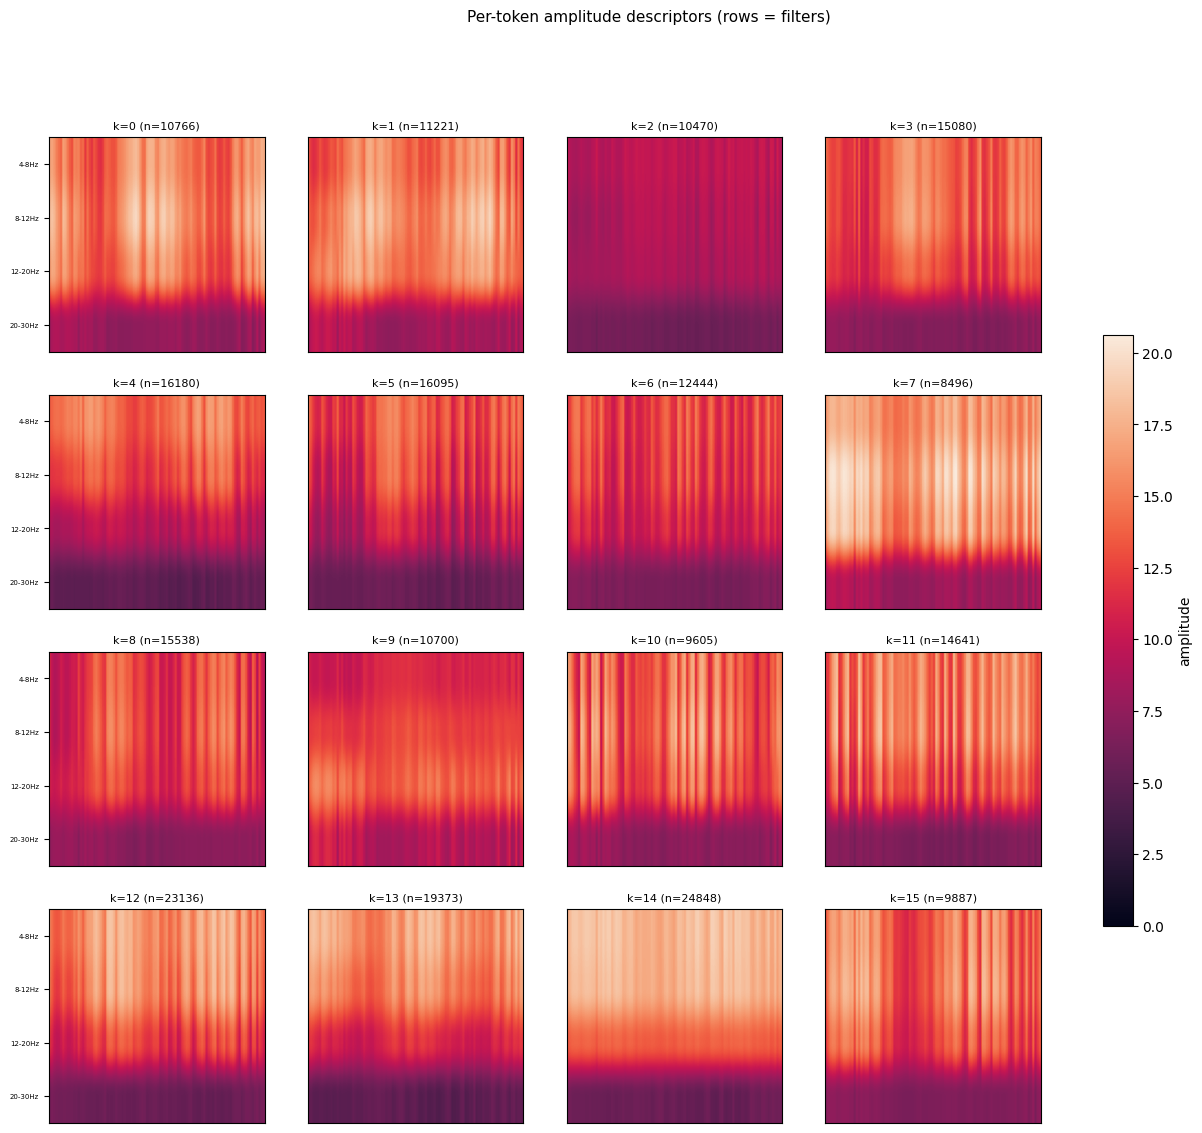

In [11]:
unpack = UNPACK[DESCRIPTOR]

def token_matrix(vec):
    """Return a (N_filt, n_features) matrix + column labels for plotting."""
    u = unpack(vec, N_FILT, C)
    if u['kind'] == 'amplitude':
        return u['data'].numpy(), [f'Ch{c}' for c in range(C)]
    if u['kind'] == 'coherence':
        return u['data'].numpy(), pair_labels
    if u['kind'] == 'complex_correlation':
        mat = np.concatenate([u['real'].numpy(), u['imag'].numpy()], axis=1)
        return mat, [f'Re {p}' for p in pair_labels] + [f'Im {p}' for p in pair_labels]
    if u['kind'] == 'cross_spectral':
        mat = np.concatenate([u['diag'].numpy(), u['real'].numpy(), u['imag'].numpy()], axis=1)
        cols = [f'P{c}' for c in range(C)] + [f'Re {p}' for p in pair_labels] + [f'Im {p}' for p in pair_labels]
        return mat, cols

ncols = min(CODEBOOK_SIZE, 4)
nrows = int(np.ceil(CODEBOOK_SIZE / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3.2))
axes = np.array(axes).reshape(-1)
mats = [token_matrix(cb_desc[k])[0] for k in range(CODEBOOK_SIZE)]
vmax = max(np.abs(m).max() for m in mats); vmin = 0 if model.nonnegative else -vmax
cmap = 'rocket'
_, col_labels = token_matrix(cb_desc[0])
for k in range(CODEBOOK_SIZE):
    ax = axes[k]
    im = ax.imshow(mats[k], aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(f'k={k} (n={int(cb_counts[k])})', fontsize=8)
    if len(col_labels) <= 12:
        ax.set_xticks(range(len(col_labels))); ax.set_xticklabels(col_labels, fontsize=5, rotation=90)
    else:
        ax.set_xticks([])
    if k % ncols == 0:
        ax.set_yticks(range(N_FILT)); ax.set_yticklabels(freq_labels, fontsize=5)
    else:
        ax.set_yticks([])
for k in range(CODEBOOK_SIZE, len(axes)): axes[k].axis('off')
fig.colorbar(im, ax=axes.tolist(), shrink=0.6, label=DESCRIPTOR)
plt.suptitle(f'Per-token {DESCRIPTOR} descriptors (rows = filters)', fontsize=11)
plt.show()

# Token Sequence Analysis

Analyses the discrete token sequence produced by the Hilbert VQ-VAE, using the
experimental-condition labels that were **not** seen during codebook learning.

Each instance is one chunk = one token; instances form a time sequence, and
same-condition instances were concatenated into contiguous runs. This notebook:

1. relabels tokens **A, B, C, ...** by frequency (most common first; `AA`..`ZZ` past 26),
2. shows the **token distribution per condition**,
3. draws a **recurrence plot per run**, grouped by condition,
4. finds **dwells** (a token held over consecutive instances),
5. finds **motifs** (repeated multi-token subsequences), aggregated per condition,
6. reports **RQA metrics** per run and condition.

Works with amplitude or coherence token files — just change the paths. The codebook
is optional; if given, token descriptors are shown alongside the analyses.


I skipped.

In [12]:
import string
from collections import Counter

sns.set_theme(style="white", context="notebook")

# ── paths: point these at your files (amplitude OR coherence) ──
CODEBOOK_NPZ = SAVE_PREFIX + "_codebook.npz"
# ── analysis parameters ──
# MIN_MOTIF_LEN = 3      # shortest repeated subsequence counted as a motif
# MIN_DWELL_LEN = 2      # shortest consecutive same-token run counted as a dwell

# channel names (for codebook descriptor plots); order must match the model
MONTAGE = "GSN-HydroCel-128" 

## Load, align, and relabel

One token per instance, aligned 1:1 with the condition labels. Tokens are relabelled
`A, B, C, ...` by their frequency over this recording (most common = `A`).

In [13]:
def code_labels(n):
    out = []
    for i in range(n):
        if i < 26:
            out.append(string.ascii_uppercase[i])
        else:
            j = i - 26
            out.append(string.ascii_uppercase[j // 26] + string.ascii_uppercase[j % 26])
    return out
    
snr_to_label = {
    0.5: 0,
    1.0: 1,
    2.0: 2,
}

conditions = np.array([snr_to_label[x] for x in snrvec], dtype=np.int64)

In [14]:
# tokens: one token id per window per instance, taken straight from the model
# (`tok` = collect_tokens(model, full_loader), hop = STRIDE_SAMPLES). Because the
# model re-tokenises the same hop-aligned chunks it was trained on, no external
# tokens file is needed.
_tok2d = tok.reshape(N_instances, N_WINDOWS)
_tpi = [np.asarray(_tok2d[j], dtype=np.int64) for j in range(N_instances)]
win_per_inst = np.array([len(x) for x in _tpi])
print(f"tokens from model: {N_instances} instances x {N_WINDOWS} windows "
      f"(hop=STRIDE_SAMPLES={STRIDE_SAMPLES})")

if win_per_inst.max() > 1:
    print(f"NOTE: instances have {win_per_inst.max()} windows each; "
          f"letter plots below use the first token of each instance unless noted.")

tokens = np.array([int(x[0]) for x in _tpi])

assert len(tokens) == len(conditions), \
    f"{len(tokens)} tokens vs {len(conditions)} labels — must match 1:1"

# the codebook is REQUIRED: token letters are keyed to its usage counts so that
# labels are authoritative and consistent with the codebook-visualisation notebook.
if not CODEBOOK_NPZ:
    raise ValueError("CODEBOOK_NPZ must be set — the codebook is required so that "
                     "token letters are keyed to its usage counts.")
codebook = np.load(CODEBOOK_NPZ, allow_pickle=True)
if "counts" not in codebook.files:
    raise KeyError("codebook .npz has no 'counts' — cannot key token letters to it.")

# relabel tokens A, B, C, ... by codebook usage, most common first
_uniq = np.unique(tokens)
cb_counts = codebook["counts"].astype(int)
used = np.where(cb_counts > 0)[0]
order_ids = used[np.argsort(-cb_counts[used], kind="stable")]

# sanity: every token in this recording must be a used codebook entry
missing = set(int(t) for t in _uniq) - set(int(t) for t in order_ids)
if missing:
    raise ValueError(f"tokens {sorted(missing)} appear in the data but are not used "
                     f"in the codebook — tokens and codebook do not match. "
                     f"Check that the model and CODEBOOK_NPZ are from the same run.")
label_basis = "codebook usage counts"

letters   = code_labels(len(order_ids))
id2letter = {int(t): letters[i] for i, t in enumerate(order_ids)}
n_codes   = len(order_ids)

# colour per letter (categorical)
_pal = sns.color_palette("husl", n_codes)
letter_color = {letters[i]: _pal[i] for i in range(n_codes)}

# runs: contiguous blocks of the same condition
_ch = np.where(np.diff(conditions) != 0)[0] + 1
_bd = np.concatenate([[0], _ch, [len(conditions)]])
runs = [(int(conditions[_bd[i]]), int(_bd[i]), int(_bd[i+1])) for i in range(len(_bd)-1)]
conditions_present = sorted(set(conditions.tolist()))

# group runs by condition: {cond: [(run_idx, start, end), ...]}
runs_by_cond = {c: [] for c in conditions_present}
for _k, (_c, _s, _e) in enumerate(runs):
    runs_by_cond[_c].append((_k, _s, _e))

# full temporal token-letter sequence for a run: EVERY window of EVERY instance
# in [s:e], in order (instances are temporally ordered, and so are windows within
# each instance). use this so dwells/motifs span all tokens of each instance
# (up to 23), not just the first token per instance.
def run_letters(s, e):
    return [id2letter[int(t)] for i in range(s, e) for t in _tpi[i]]

print(f"{len(tokens)} instances, {n_codes} distinct tokens, "
      f"{len(runs)} runs, conditions {conditions_present}")
print("\ntoken  id   count")
for i, t in enumerate(order_ids):
    print(f"  {letters[i]:<4} {int(t):>3}  {int(cb_counts[used][list(_uniq).index(t)]):>5}")

print(f"\ncodebook loaded: descriptor = {str(codebook['descriptor'])}")
print(f"token labels keyed to: {label_basis}")


tokens from model: 3360 instances x 68 windows (hop=STRIDE_SAMPLES=25)
NOTE: instances have 68 windows each; letter plots below use the first token of each instance unless noted.
3360 instances, 16 distinct tokens, 590 runs, conditions [0, 1, 2]

token  id   count
  A     14  24849
  B     12  23135
  C     13  19373
  D      4  16180
  E      5  16095
  F      8  15538
  G      3  15080
  H     11  14641
  I      6  12444
  J      1  11221
  K      0  10766
  L      9  10700
  M      2  10470
  N     15   9887
  O     10   9605
  P      7   8496

codebook loaded: descriptor = amplitude
token labels keyed to: codebook usage counts


## Token distribution per condition

How often each token occurs within each experimental condition.

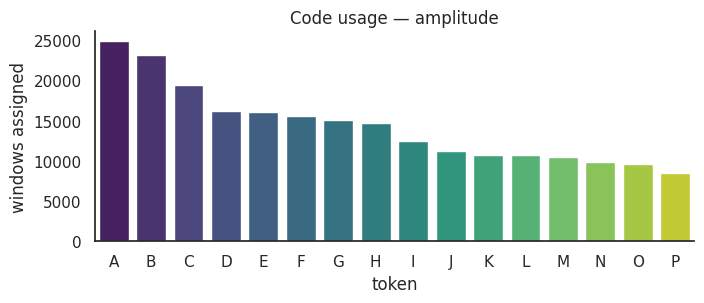

In [15]:
fig, ax = plt.subplots(figsize=(max(6, len(order_ids)*0.45), 3.2))
sns.barplot(x=letters, y=cb_counts[order_ids], hue=letters, palette="viridis",
            legend=False, ax=ax)
ax.set_xlabel("token")
ax.set_ylabel("windows assigned")
ax.set_title(f"Code usage — {descriptor}")
sns.despine()
plt.tight_layout()
plt.show()

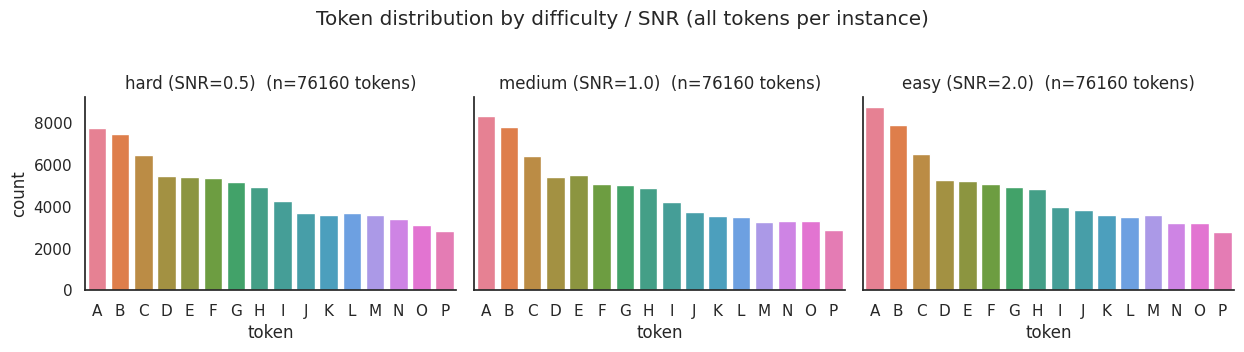

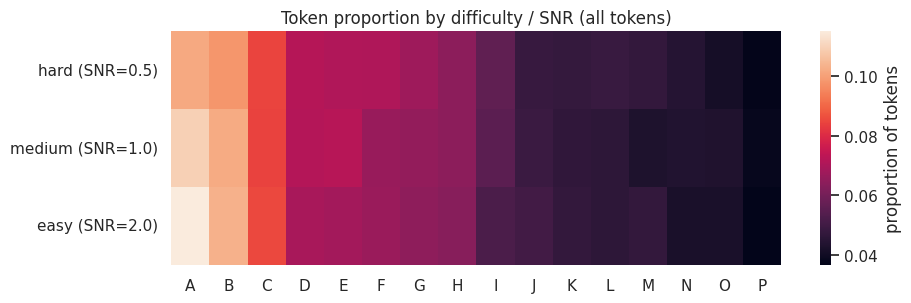

In [16]:
# count ALL tokens of each instance (an instance can hold up to 23 windows),
# not just the first token: expand every window to a (letter, condition) pair.
letter_all = np.array([id2letter[int(t)] for inst in _tpi for t in inst])
cond_all   = np.array([conditions[i]     for i, inst in enumerate(_tpi) for _ in inst])

# map integer condition ids (0/1/2) back to SNR difficulty titles from SNR_LEVELS
cond_to_title = {snr_to_label[snr]: label for snr, label in SNR_LEVELS}

fig, axes = plt.subplots(1, len(conditions_present),
                         figsize=(4.2*len(conditions_present), 3.4), sharey=True)
if len(conditions_present) == 1:
    axes = [axes]
for ax, cond in zip(axes, conditions_present):
    mask = cond_all == cond
    cnt  = Counter(letter_all[mask])
    ys   = [cnt.get(L, 0) for L in letters]
    sns.barplot(x=letters, y=ys, hue=letters, palette=letter_color, legend=False, ax=ax)
    ax.set_title(f"{cond_to_title[cond]}  (n={int(mask.sum())} tokens)")
    ax.set_xlabel("token")
axes[0].set_ylabel("count")
fig.suptitle("Token distribution by difficulty / SNR (all tokens per instance)", y=1.03)
sns.despine()
plt.tight_layout()
plt.show()

# also as normalised proportions, side by side
prop = np.zeros((len(conditions_present), n_codes))
for r, cond in enumerate(conditions_present):
    mask = cond_all == cond
    cnt = Counter(letter_all[mask])
    tot = mask.sum()
    prop[r] = [cnt.get(L, 0)/tot for L in letters]
fig, ax = plt.subplots(figsize=(max(6, n_codes*0.6), 3.2))
sns.heatmap(prop, ax=ax, cmap="rocket", xticklabels=letters,
            yticklabels=[cond_to_title[c] for c in conditions_present],
            cbar_kws={"label": "proportion of tokens"})
ax.set_title("Token proportion by difficulty / SNR (all tokens)")
plt.tight_layout()
plt.show()


## Window-by-position heatmaps (pruned + relabelled alphabet)

Code usage by window position, plotted so that we (1) keep only the codes
actually used in the codebook (pruned codes dropped) and (2) order and label the
rows by the `A, B, C, ...` alphabet built in *Load, align, and relabel*
(`order_ids` / `id2letter` / `letters`, most-used = `A`).


redoing heatmaps with 16 used codes (of K=16); letters A..P


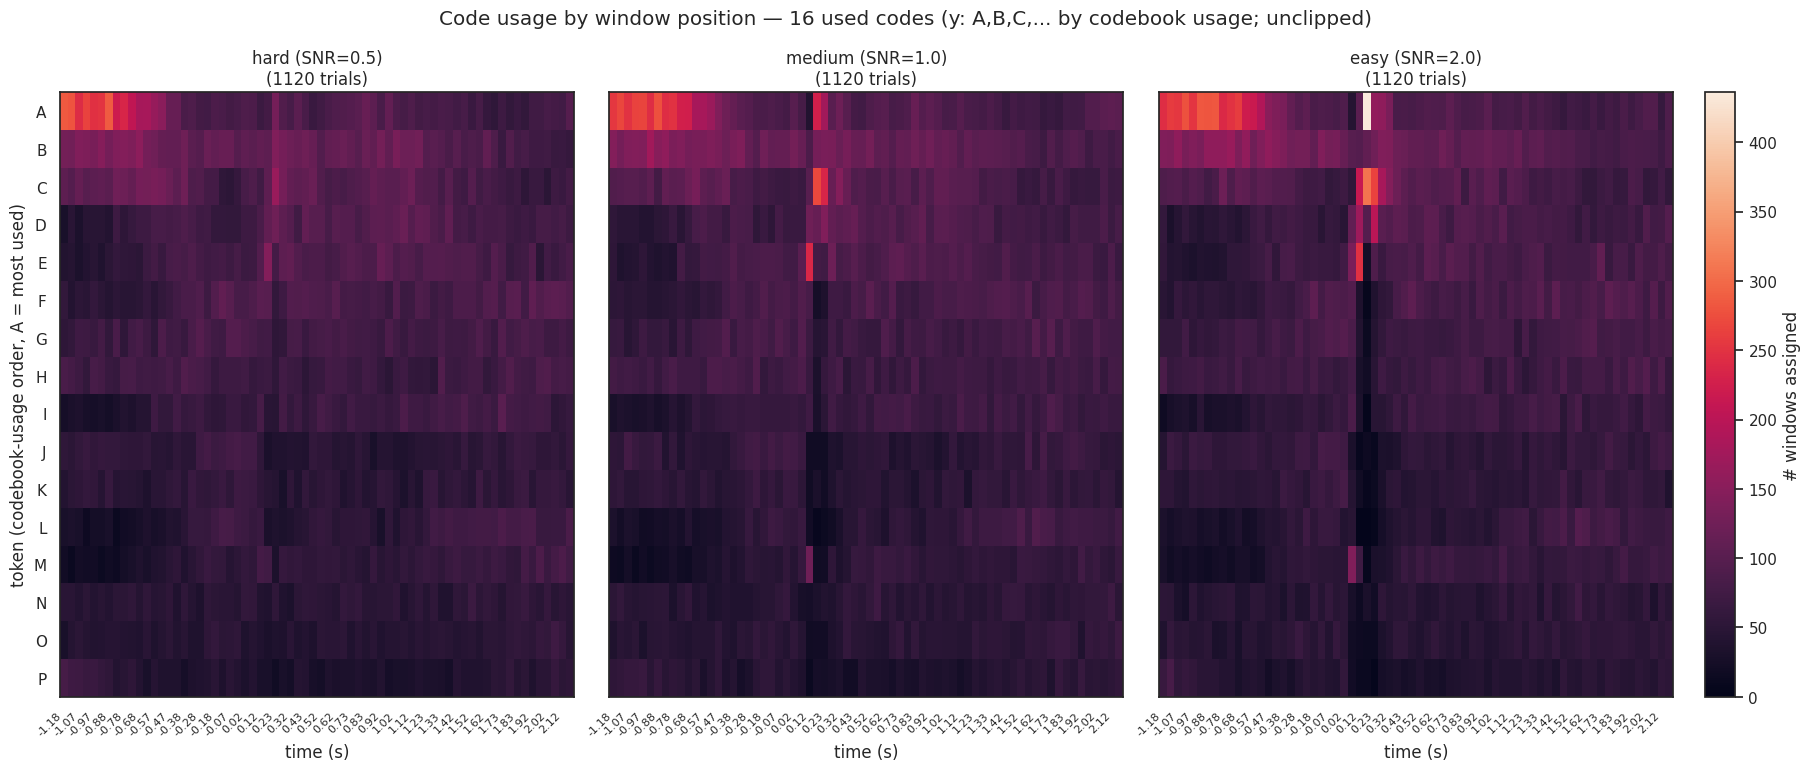

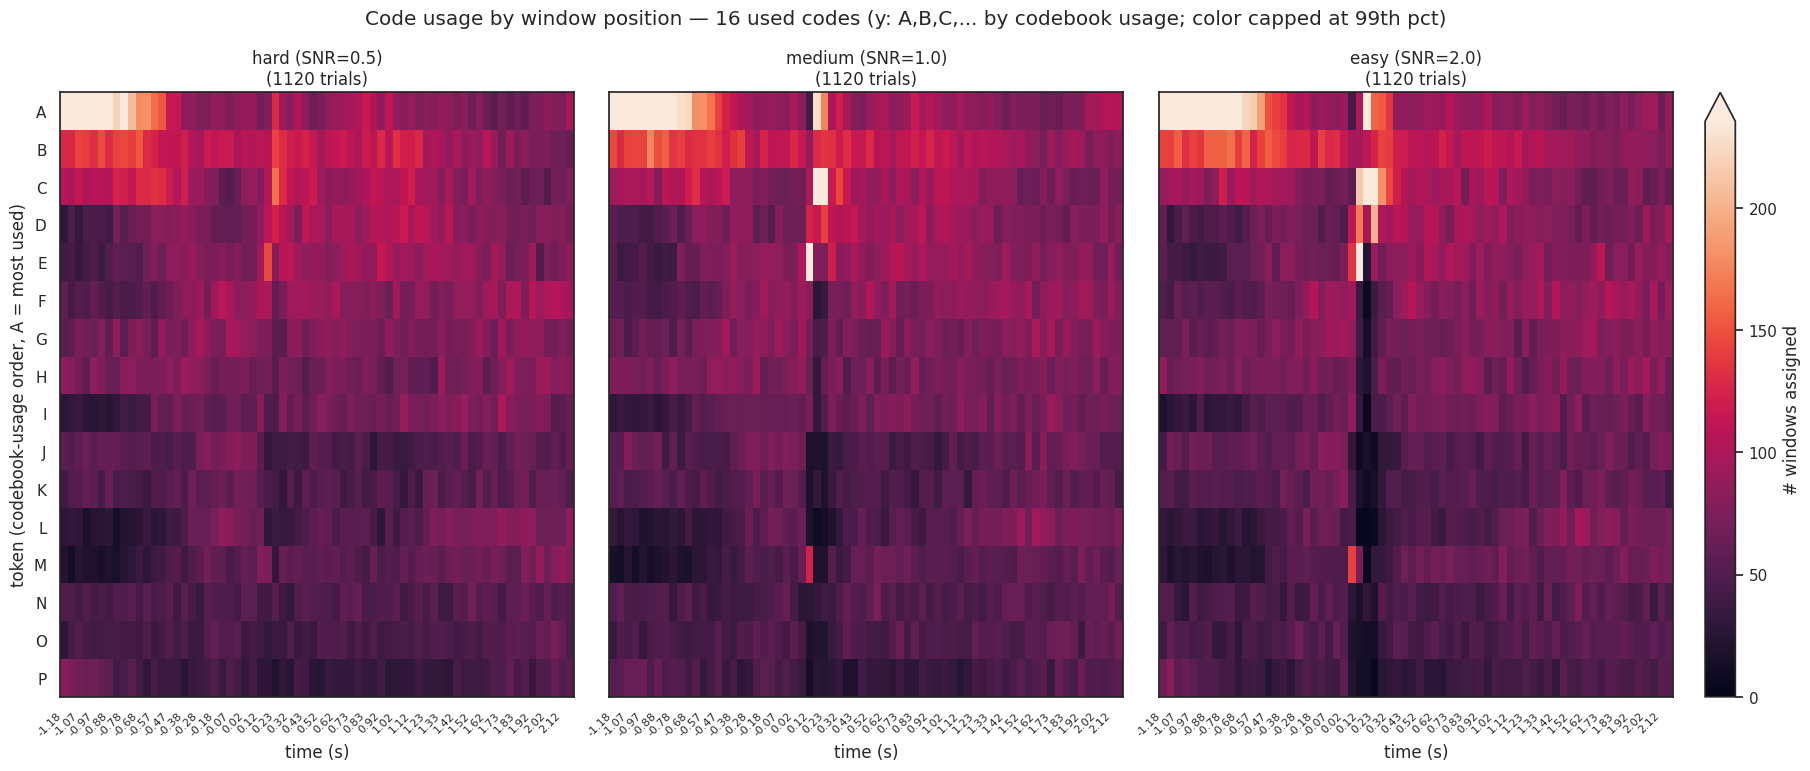

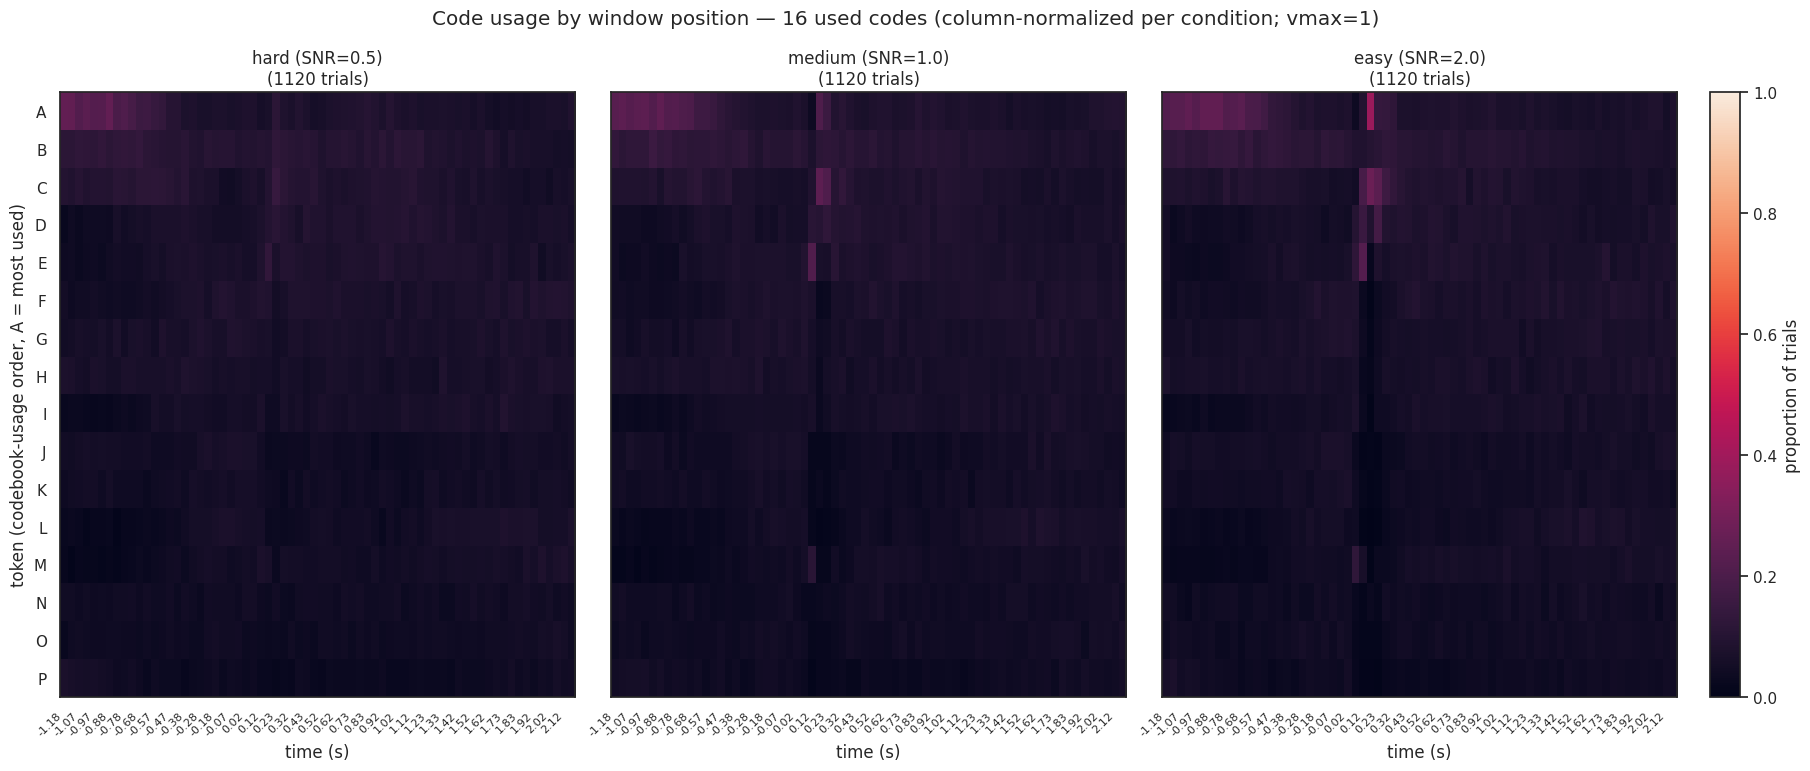

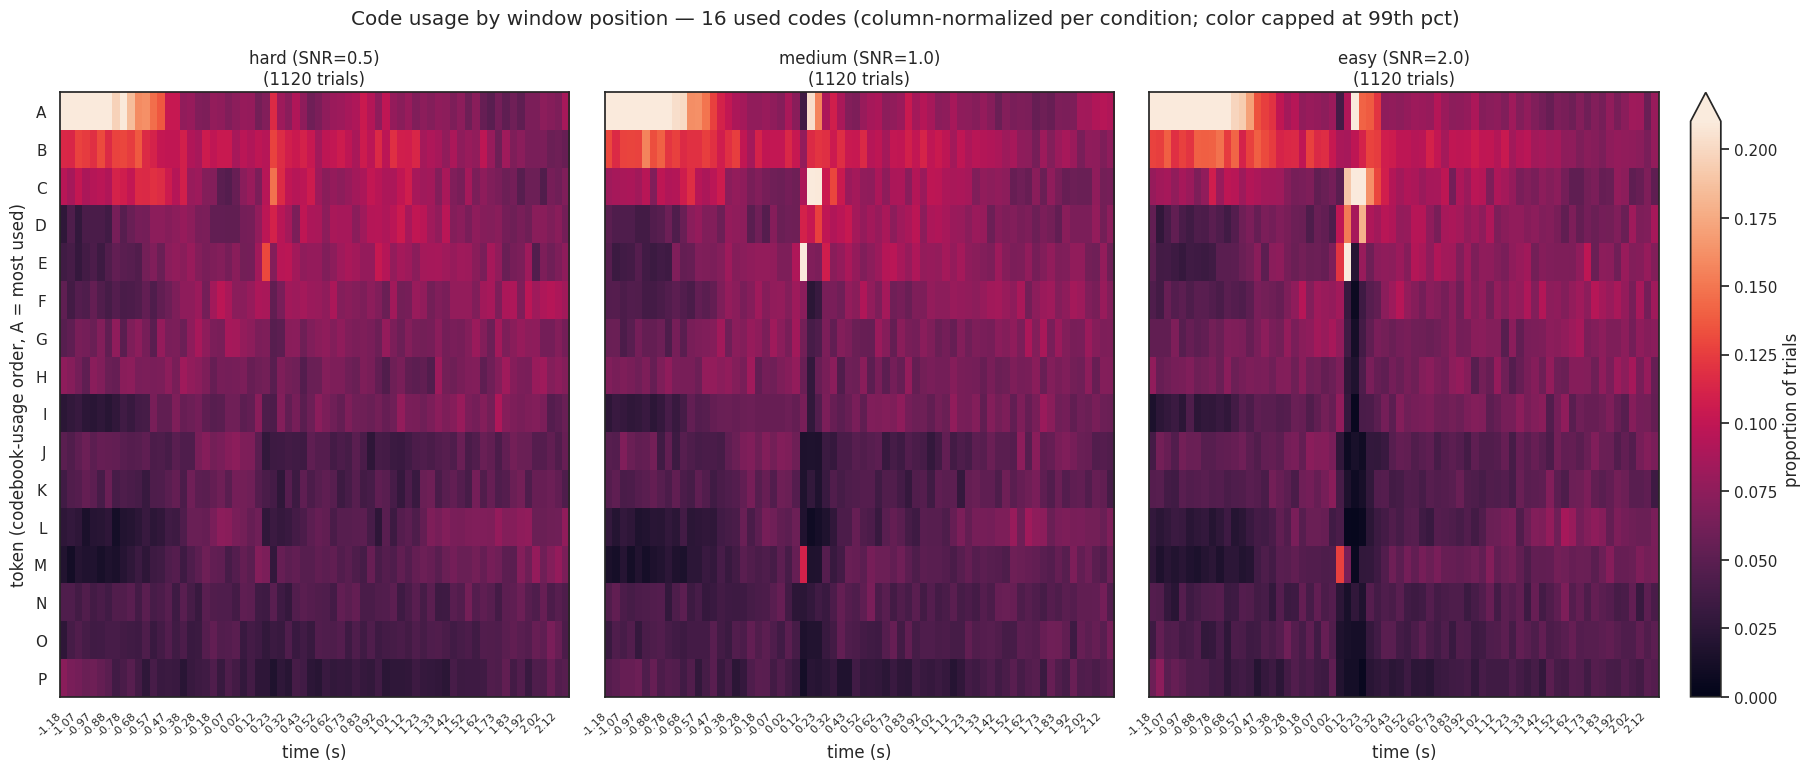

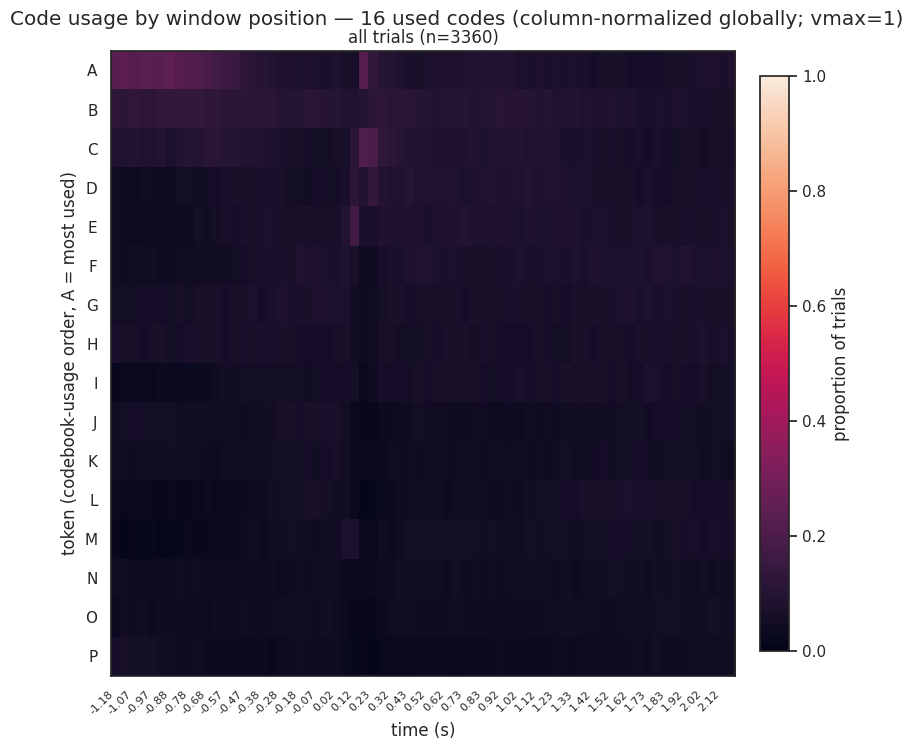

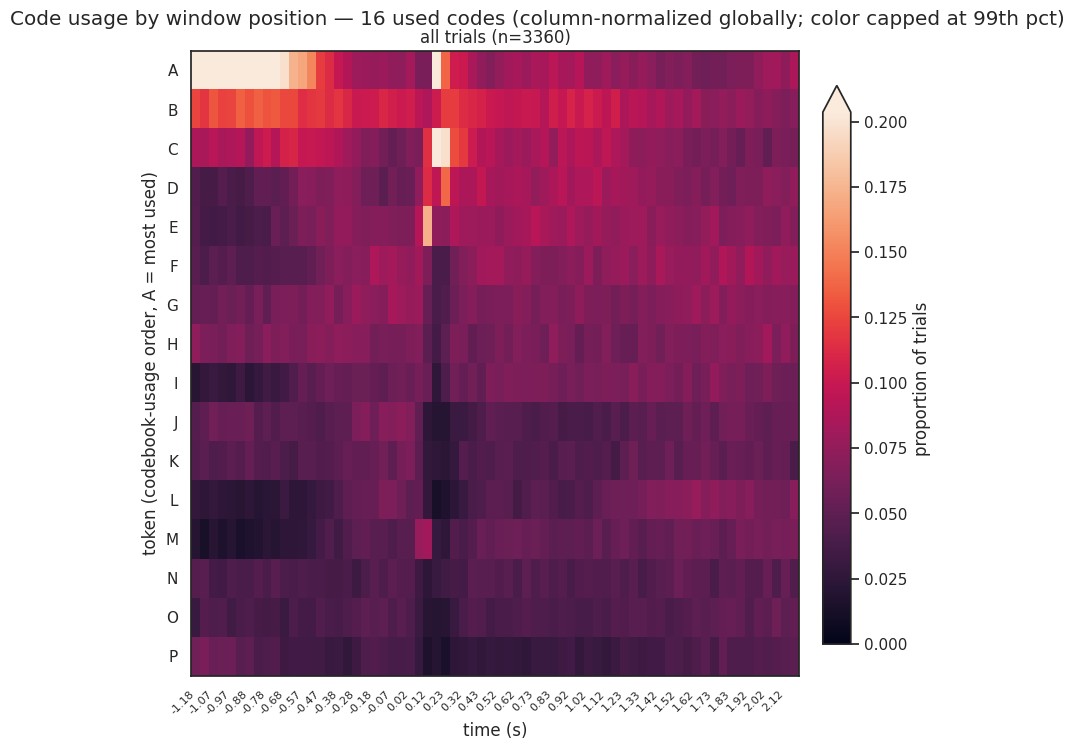

In [17]:
# Redo the window-by-position heatmaps using the relabelled alphabet.
# Rows = ONLY the codes actually used in the codebook (pruned codes dropped),
# ordered by codebook usage (A = most used), taken from the alignment cell:
# order_ids: code ids in A, B, C, ... order
# letters: matching letters
# n_codes: number of used codes


# the bottom "Token Sequence Analysis" section overwrote `tokens` with a 1-D
# (first-token-per-instance) array, so rebuild the per-window 2-D matrix here.
tokens_2d = tok.reshape(N_instances, N_WINDOWS)

row_ids     = np.asarray(order_ids)   # codebook-used code ids, A,B,C,... order
row_letters = list(letters)           # matching letters
n_rows      = n_codes
YLABEL      = "token (codebook-usage order, A = most used)"
CLIP_PERCENTILE = 99


def _letter_yaxis(ax, show_labels=True):
    ax.set_yticks(np.arange(n_rows))
    ax.set_yticklabels(row_letters if show_labels else [])
    if show_labels:
        ax.set_ylabel(YLABEL)


# `time` holds the true window-onset times (s). imshow draws window positions at
# integer pixel centres 0..N_WINDOWS-1, so put the ticks at those positions and
# use the onset times as the *labels* (set_xticks(time) would instead place ticks
# at the coordinate values -1.25..2.05, which is wrong for an index axis).
assert len(time) == N_WINDOWS, f"time has {len(time)} entries, expected N_WINDOWS={N_WINDOWS}"

def _time_xaxis(ax, stride=2):
    pos = np.arange(N_WINDOWS)
    ax.set_xticks(pos[::stride])
    ax.set_xticklabels([f"{time[p]:.2f}" for p in pos[::stride]],
                       rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("time (s)")


print(f"redoing heatmaps with {n_rows} used codes (of K={CODEBOOK_SIZE}); "
      f"letters A..{row_letters[-1]}")

# ---------------------------------------------------------------------------
# per-SNR RAW COUNTS  (unclipped, then color-capped at 99th pct)
# ---------------------------------------------------------------------------
pos_counts_by_snr = {}
plot_vals = []
for snr, label in SNR_LEVELS:
    trials = np.where(snrvec == snr)[0]
    pc = code_usage_per_position(tokens_2d[trials], N_WINDOWS, CODEBOOK_SIZE)
    pos_counts_by_snr[snr] = pc
    plot_vals.append(pc[:, row_ids])
plot_vals = np.concatenate(plot_vals)

for clip in (None, CLIP_PERCENTILE):
    # unclipped: share ONE vmax (max across all conditions) so the colorbar is
    # truly comparable across the three subplots, not autoscaled per panel.
    vmax   = plot_vals.max() if clip is None else max(1, np.percentile(plot_vals, clip))
    extend = "neither" if clip is None else "max"
    cap    = "unclipped" if clip is None else f"color capped at {clip}th pct"
    fig, axes = plt.subplots(1, 3, figsize=(18, max(4.5, 0.45 * n_rows)),
                             constrained_layout=True)
    for ax, (snr, label) in zip(axes, SNR_LEVELS):
        im = ax.imshow(pos_counts_by_snr[snr][:, row_ids].T, aspect="auto",
                       origin="upper", cmap="rocket", vmin=0, vmax=vmax)
        _time_xaxis(ax)
        ax.set_title(f"{label}\n({int(np.sum(snrvec == snr))} trials)")
        _letter_yaxis(ax, show_labels=(ax is axes[0]))
    fig.colorbar(im, ax=axes, label="# windows assigned",
                 fraction=0.025, pad=0.02, extend=extend)
    fig.suptitle(f"Code usage by window position — {n_rows} used codes "
                 f"(y: A,B,C,... by codebook usage; {cap})", y=1.05)
    plt.show()

# ---------------------------------------------------------------------------
# per-SNR PROPORTIONS  P(token | window)   (vmax=1, then capped at 99th pct)
# ---------------------------------------------------------------------------
pos_props_by_snr = {}
plot_vals = []
for snr, label in SNR_LEVELS:
    pc = pos_counts_by_snr[snr]
    pp = pc / pc.sum(axis=1, keepdims=True)
    pos_props_by_snr[snr] = pp
    plot_vals.append(pp[:, row_ids])
plot_vals = np.concatenate(plot_vals)

for vmax, cap, extend in [
    (1.0, "vmax=1", "neither"),
    (np.percentile(plot_vals, CLIP_PERCENTILE),
     f"color capped at {CLIP_PERCENTILE}th pct", "max"),
]:
    fig, axes = plt.subplots(1, 3, figsize=(18, max(4.5, 0.45 * n_rows)),
                             constrained_layout=True)
    for ax, (snr, label) in zip(axes, SNR_LEVELS):
        im = ax.imshow(pos_props_by_snr[snr][:, row_ids].T, aspect="auto",
                       origin="upper", cmap="rocket", vmin=0, vmax=vmax)
        _time_xaxis(ax)
        ax.set_title(f"{label}\n({int(np.sum(snrvec == snr))} trials)")
        _letter_yaxis(ax, show_labels=(ax is axes[0]))
    fig.colorbar(im, ax=axes, label="proportion of trials",
                 fraction=0.025, pad=0.02, extend=extend)
    fig.suptitle(f"Code usage by window position — {n_rows} used codes "
                 f"(column-normalized per condition; {cap})", y=1.05)
    plt.show()

# ---------------------------------------------------------------------------
# GLOBAL (all trials) PROPORTIONS  (vmax=1, then capped at 99th pct)
# ---------------------------------------------------------------------------
pos_counts_all = code_usage_per_position(tokens_2d, N_WINDOWS, CODEBOOK_SIZE)
pos_props_all  = pos_counts_all / pos_counts_all.sum(axis=1, keepdims=True)
plot_vals      = pos_props_all[:, row_ids]

for vmax, cap, extend in [
    (1.0, "vmax=1", "neither"),
    (np.percentile(plot_vals, CLIP_PERCENTILE),
     f"color capped at {CLIP_PERCENTILE}th pct", "max"),
]:
    fig, ax = plt.subplots(figsize=(8, max(4.5, 0.45 * n_rows)),
                           constrained_layout=True)
    im = ax.imshow(plot_vals.T, aspect="auto", origin="upper", cmap="rocket",
                   vmin=0, vmax=vmax)
    _time_xaxis(ax)
    _letter_yaxis(ax, show_labels=True)
    ax.set_title(f"all trials (n={len(tokens_2d)})")
    fig.colorbar(im, ax=ax, label="proportion of trials",
                 fraction=0.046, pad=0.04, extend=extend)
    fig.suptitle(f"Code usage by window position — {n_rows} used codes "
                 f"(column-normalized globally; {cap})", y=1.02)
    plt.show()


## Token diversity / entropy (pruned alphabet)

Per-window token entropy against the *achievable* ceiling of `log2(n_codes)`
over the used codes (rather than `log2(K)`, which assumes all `K` codes are
reachable — but a few were pruned). This adds a **normalized entropy**
(efficiency in `[0, 1]`) view and prints per-condition perplexity against the
used-codes basis.


entropy ceiling: log2(K=16) = 4.00 bits  ->  log2(n_codes=16) = 4.00 bits (pruned)

condition             trials  active/used   perplexity  norm-perp
  hard (SNR=0.5)       1120   16/16         15.29      0.96
  medium (SNR=1.0)     1120   16/16         15.19      0.95
  easy (SNR=2.0)       1120   16/16         15.13      0.95

I(token; SNR) per window: mean=0.0125  max=0.1842 bits  (ceiling = log2(#conditions=3) = 1.58)


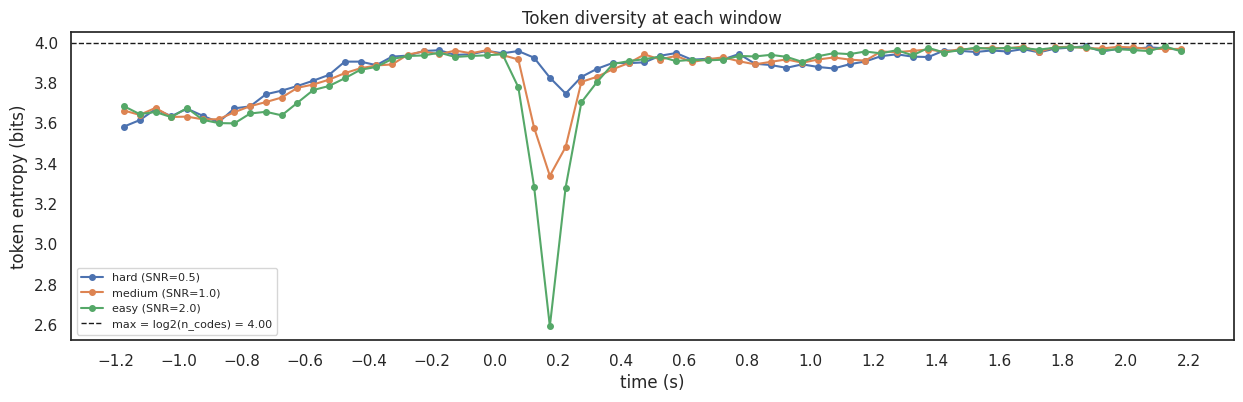

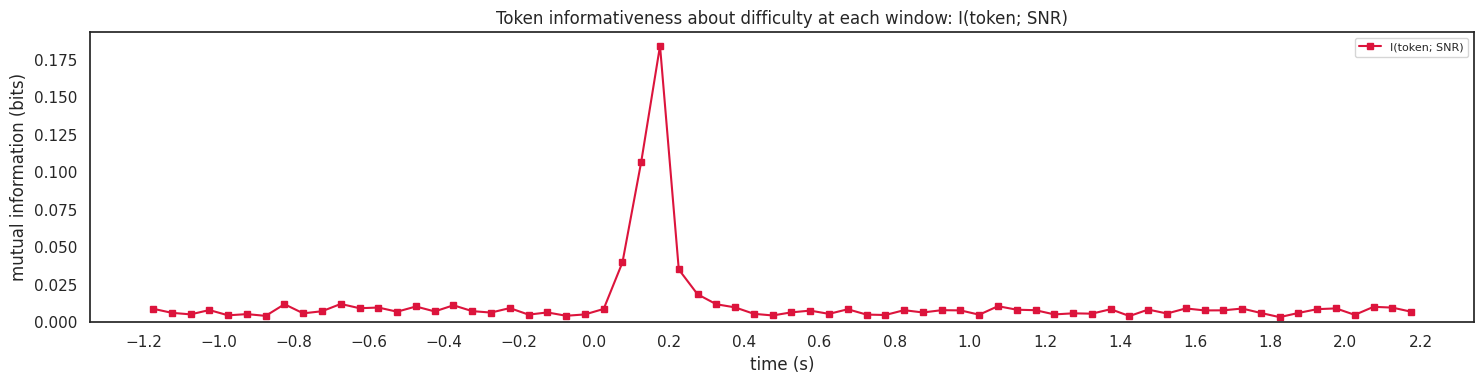


significant windows (p<0.05, 500 within-window shuffles): 17/68


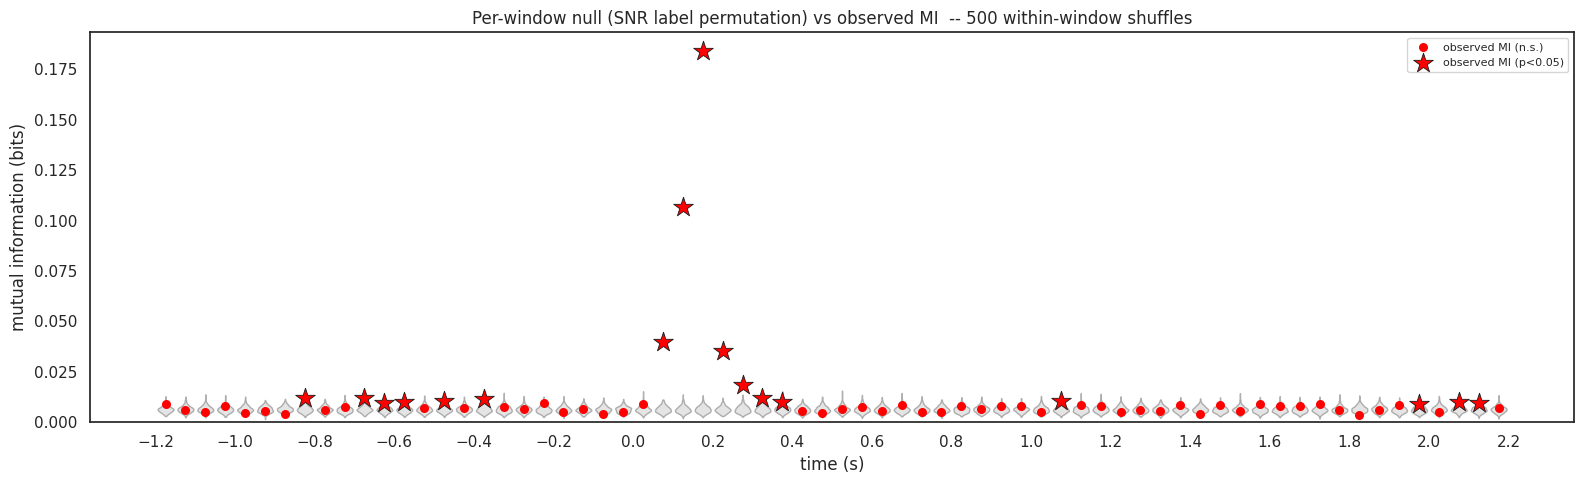

In [18]:
# ============================================================================
# Redo token-diversity (entropy / perplexity) against the PRUNED alphabet.
# Entropy values are unchanged, but the fair ceiling is log2(n_codes) over the
# used codes, not log2(K). `tokens_2d`, `n_codes`, `row_ids` come from the
# heatmap cell above; SNR_LEVELS / helpers from the top of the notebook.
# ============================================================================

max_bits_K   = np.log2(CODEBOOK_SIZE)   # old (unfair) ceiling: all K codes
max_bits_use = np.log2(n_codes)         # fair ceiling: only used codes
print(f"entropy ceiling: log2(K={CODEBOOK_SIZE}) = {max_bits_K:.2f} bits  ->  "
      f"log2(n_codes={n_codes}) = {max_bits_use:.2f} bits (pruned)")

# --- updated per-condition summary (active codes now out of n_codes) ---
print(f"\n{'condition':20s}  trials  active/used   perplexity  norm-perp")
for snr, label in SNR_LEVELS:
    trials = np.where(snrvec == snr)[0]
    counts, used_cnt, perp = code_usage_summary(tokens_2d[trials], CODEBOOK_SIZE)
    norm_perp = perp / n_codes          # 1.0 == uniform over all used codes
    print(f"  {label:18s}  {len(trials):5d}   {used_cnt:2d}/{n_codes:<2d}"
          f"        {perp:6.2f}     {norm_perp:5.2f}")

# --- entropy per window, per SNR, with the fair log2(n_codes) ceiling ---
ent_by_snr = {}
for snr, label in SNR_LEVELS:
    trials = np.where(snrvec == snr)[0]
    ent_by_snr[snr] = token_entropy_by_position(tokens_2d[trials], CODEBOOK_SIZE)

fig, ax = plt.subplots(figsize=(15, 4))

# raw entropy (bits) with both ceilings drawn for reference
for snr, label in SNR_LEVELS:
    ax.plot(time, ent_by_snr[snr], "-o", ms=4, label=label)
ax.axhline(max_bits_use, ls="--", color="k", lw=1,
            label=f"max = log2(n_codes) = {max_bits_use:.2f}")

ax.set_xlabel("time (s)")
ax.set_ylabel("token entropy (bits)")
ax.set_title("Token diversity at each window")
ax.locator_params(axis="x", nbins=20)
ax.legend(fontsize=8)

# --- mutual information per window: how much the token at each position tells
#     us about task difficulty, I(token; SNR) in bits. 0 == token distribution
#     is identical across conditions; higher == token is more condition-specific.
def token_condition_mi_by_position(indices, cond, num_codes):
    """I(token; condition) in bits at each window position."""
    idx  = np.asarray(indices)
    cond = np.asarray(cond)
    conds = np.unique(cond)
    mi = np.zeros(idx.shape[1])
    for p in range(idx.shape[1]):
        col = idx[:, p]
        joint = np.stack([np.bincount(col[cond == c], minlength=num_codes)
                          for c in conds], axis=1).astype(float)
        total = joint.sum()
        if total == 0:
            continue
        pj   = joint / total                     # P(token, cond)
        ptok = pj.sum(axis=1, keepdims=True)      # P(token)
        pcnd = pj.sum(axis=0, keepdims=True)      # P(cond)
        m    = pj > 0
        mi[p] = np.sum(pj[m] * np.log2(pj[m] / (ptok * pcnd)[m]))
    return mi

snr_values = [snr for snr, _ in SNR_LEVELS]
mask_all   = np.isin(snrvec, snr_values)
mi_pos     = token_condition_mi_by_position(tokens_2d[mask_all],
                                            snrvec[mask_all], CODEBOOK_SIZE)
print(f"\nI(token; SNR) per window: mean={mi_pos.mean():.4f}  max={mi_pos.max():.4f} bits"
      f"  (ceiling = log2(#conditions={len(snr_values)}) = {np.log2(len(snr_values)):.2f})")

# --- mutual information as its own figure ---
_, ax_mi = plt.subplots(figsize=(15, 4))
ax_mi.plot(time, mi_pos, "-s", ms=4, color="crimson", label="I(token; SNR)")

ax_mi.set_xlabel("time (s)")
ax_mi.set_ylabel("mutual information (bits)")
ax_mi.set_title("Token informativeness about difficulty at each window: I(token; SNR)")
ax_mi.set_ylim(bottom=0)
ax_mi.locator_params(axis="x", nbins=20)
ax_mi.legend(fontsize=8)
plt.tight_layout()
plt.show()

# --- permutation null: is the observed MI above chance? -----------------------
# For each shuffle we permute the SNR labels *independently within each window*,
# which destroys any token<->condition association while preserving the per-
# window token marginals and the label marginal. Recompute normalized MI each
# time to build a null distribution, then compare the observed curve/peak to it.
mi_ceiling = np.log2(len(snr_values))     # max possible MI = log2(#conditions)

def _col_mi(col, cond, num_codes, conds):
    """I(token; cond) in bits for a single window column."""
    joint = np.stack([np.bincount(col[cond == c], minlength=num_codes)
                      for c in conds], axis=1).astype(float)
    total = joint.sum()
    if total == 0:
        return 0.0
    pj   = joint / total
    ptok = pj.sum(axis=1, keepdims=True)
    pcnd = pj.sum(axis=0, keepdims=True)
    m    = pj > 0
    return float(np.sum(pj[m] * np.log2(pj[m] / (ptok * pcnd)[m])))

N_SHUFFLES = 500
rng        = np.random.default_rng(0)
tok_all    = tokens_2d[mask_all]
cond_all   = snrvec[mask_all]
conds      = np.unique(cond_all)
n_pos      = tok_all.shape[1]

null_norm = np.zeros((N_SHUFFLES, n_pos))
for s in range(N_SHUFFLES):
    for p in range(n_pos):
        shuffled = rng.permutation(cond_all)          # within-window label shuffle
        null_norm[s, p] = _col_mi(tok_all[:, p], shuffled, CODEBOOK_SIZE, conds) / mi_ceiling

# null distribution in bits, kept separate per window position (no mixing)
null_bits = null_norm * mi_ceiling                    # (N_SHUFFLES, n_pos)
obs_bits  = mi_pos                                     # observed MI per window

# one-sided permutation p-value per window, then flag significance
p_win = (1 + np.sum(null_bits >= obs_bits[None, :], axis=0)) / (N_SHUFFLES + 1)
sig   = p_win < 0.05
print(f"\nsignificant windows (p<0.05, {N_SHUFFLES} within-window shuffles): "
      f"{int(sig.sum())}/{n_pos}")

_, axv = plt.subplots(figsize=(16, 5))
dt = float(np.median(np.diff(time))) if n_pos > 1 else 1.0
parts = axv.violinplot([null_bits[:, p] for p in range(n_pos)],
                       positions=time, widths=0.8 * dt, showextrema=False)
for pc in parts["bodies"]:
    pc.set_facecolor("lightgrey")
    pc.set_edgecolor("grey")
    pc.set_alpha(0.6)

# observed MI: red dot if n.s., red star if significant
axv.scatter(time[~sig], obs_bits[~sig], color="red", s=30, zorder=5,
            label="observed MI (n.s.)")
axv.scatter(time[sig], obs_bits[sig], marker="*", color="red", s=220,
            edgecolor="k", linewidths=0.6, zorder=6, label="observed MI (p<0.05)")

axv.set_xlabel("time (s)")
axv.set_ylabel("mutual information (bits)")
axv.set_title(f"Per-window null (SNR label permutation) vs observed MI "
              f" -- {N_SHUFFLES} within-window shuffles")
axv.set_ylim(bottom=0)
axv.locator_params(axis="x", nbins=20)
axv.legend(fontsize=8)
plt.tight_layout()
plt.show()



### Response-Locked Figures

In [19]:
reaction_time = dataset["rt"]

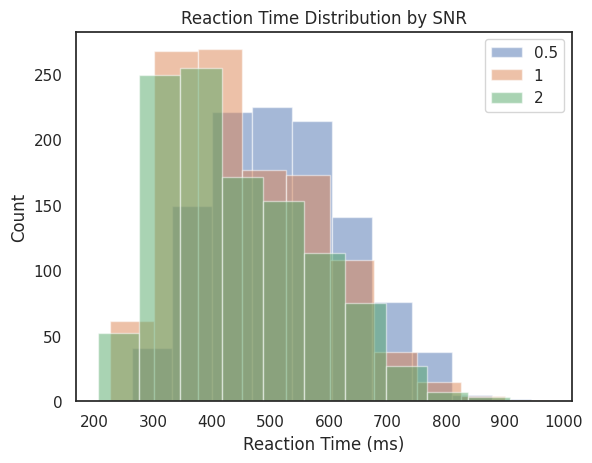

In [20]:
reaction_time_snr05 =(reaction_time / 1000 * FS)[snrvec == 0.5]
reaction_time_snr1 =(reaction_time / 1000 * FS)[snrvec == 1]
reaction_time_snr2 =(reaction_time / 1000 * FS)[snrvec == 2]

plt.hist(reaction_time_snr05, alpha=0.5, label="0.5")
plt.hist(reaction_time_snr1, alpha=0.5, label="1")
plt.hist(reaction_time_snr2, alpha=0.5, label="2")
plt.xlabel("Reaction Time (ms)")
plt.ylabel("Count")
plt.title("Reaction Time Distribution by SNR")
plt.legend()
plt.show()

* should grab the RT as the onset, then grab 300 ms before it and 300 after it for a total of 600 ms. do 150 ms chunks with 100 ms overlap.



In [21]:
# ── Response-locked epochs ──────────────────────────────────────────────
# Use RT as the onset (t=0), then grab 300 ms before and 300 ms after it ->
# 600 ms per trial. Each epoch is later split into overlapping 150 ms windows
# (100 ms overlap) so the response-locked chunking matches the rest of the notebook.
PRE_SEC  = 0.400   # 300 ms before RT
POST_SEC = 0.300   # 300 ms after RT
PRE_SAMPLES   = int(PRE_SEC  * FS)
POST_SAMPLES  = int(POST_SEC * FS)
TOTAL_SAMPLES = PRE_SAMPLES + POST_SAMPLES

C_data = data.shape[1]
T_data = data.shape[-1]
stim_onset_idx = int(1.25 * FS)          # stimulus (t=0) sits at this sample

# response-sample index for EVERY trial (NaN where RT is missing)
rt_sample = np.round(reaction_time / 1000 * FS) + stim_onset_idx
start_all = rt_sample - PRE_SAMPLES
end_all   = rt_sample + POST_SAMPLES

# keep trials with a valid RT AND whose full 600 ms window fits inside the epoch
nan_rt_mask = np.isnan(reaction_time)
inbounds    = (start_all >= 0) & (end_all <= T_data)   # NaN comparisons -> False
valid       = (~nan_rt_mask) & inbounds
valid_trials = np.where(valid)[0]

n_valid   = len(valid_trials)
start_idx = start_all[valid].astype(int)

response_locked_data = np.zeros((n_valid, C_data, TOTAL_SAMPLES))
for k, (trial, s) in enumerate(zip(valid_trials, start_idx)):
    response_locked_data[k] = data[trial, :, s:s + TOTAL_SAMPLES]

# aligned metadata for the per-condition (SNR) response-locked figures
rl_snr = snrvec[valid_trials]

n_nan = int(nan_rt_mask.sum())
n_oob = int(((~nan_rt_mask) & ~inbounds).sum())
print(f"response_locked_data: {response_locked_data.shape}")
print(f"kept {n_valid}/{len(reaction_time)} trials "
      f"(dropped {n_nan} NaN-RT, {n_oob} out-of-bounds)")



response_locked_data: (3330, 98, 350)
kept 3330/3360 trials (dropped 29 NaN-RT, 1 out-of-bounds)


response-locked tokens: (3330, 11)
response-locked heatmaps with 16 used codes (of K=16); letters A..P


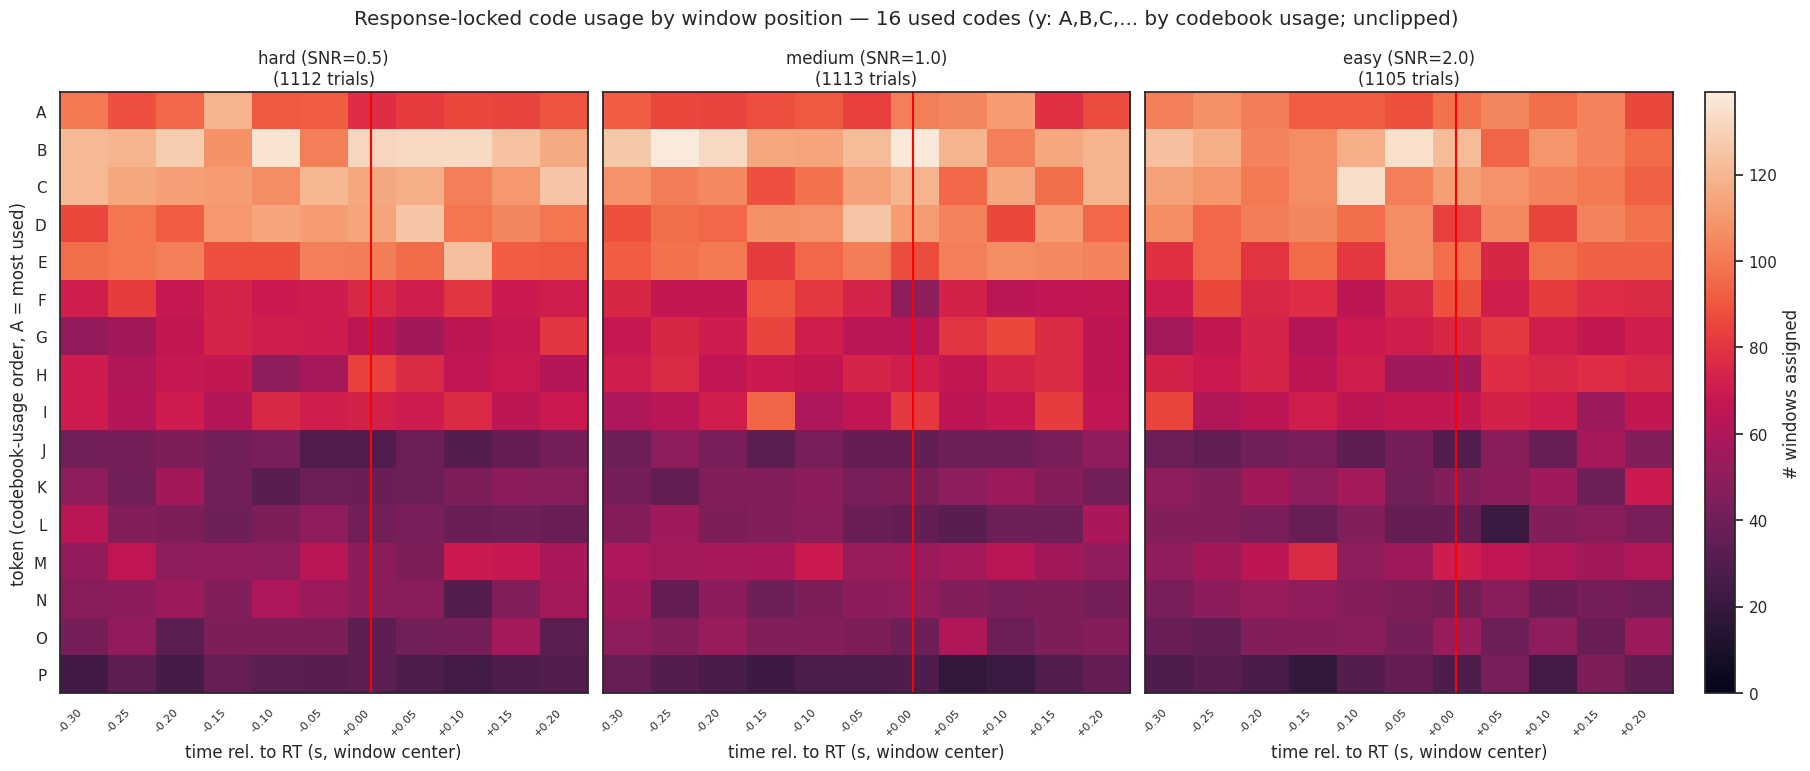

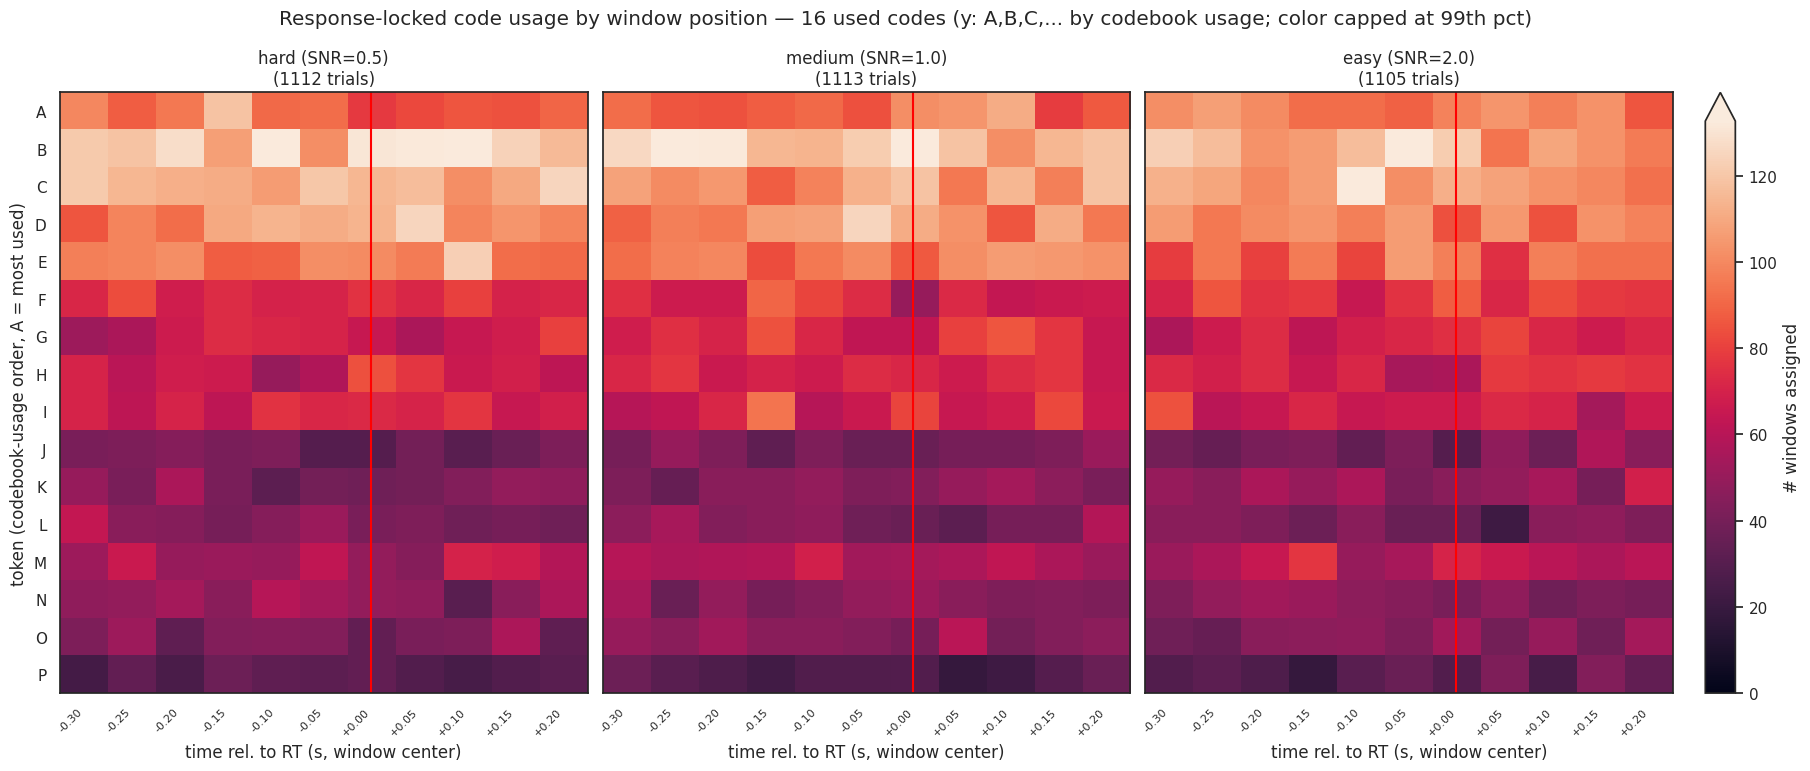

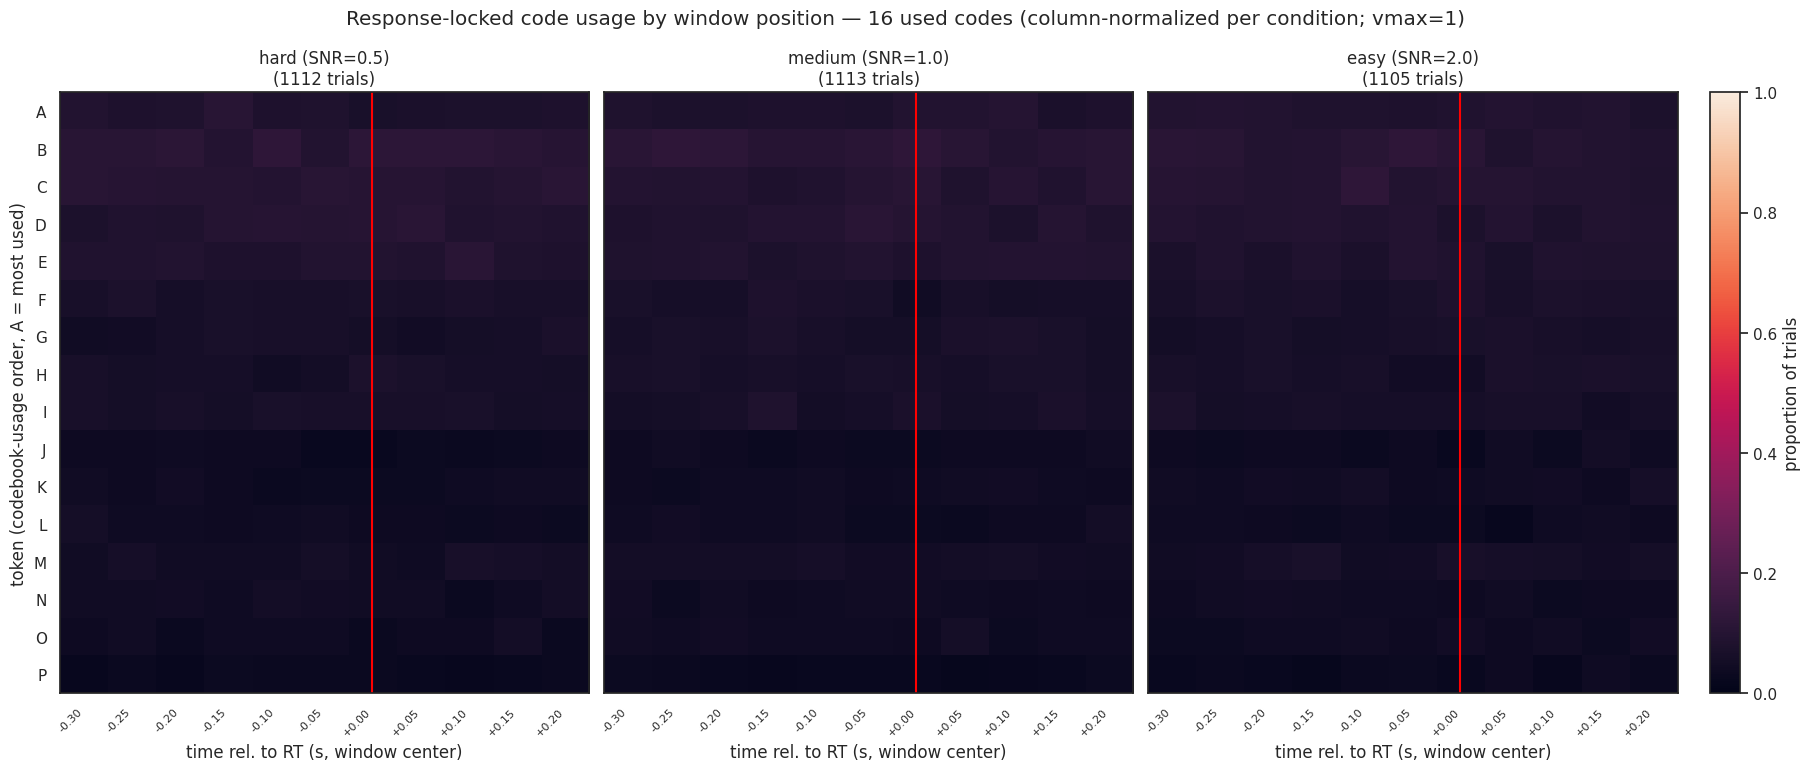

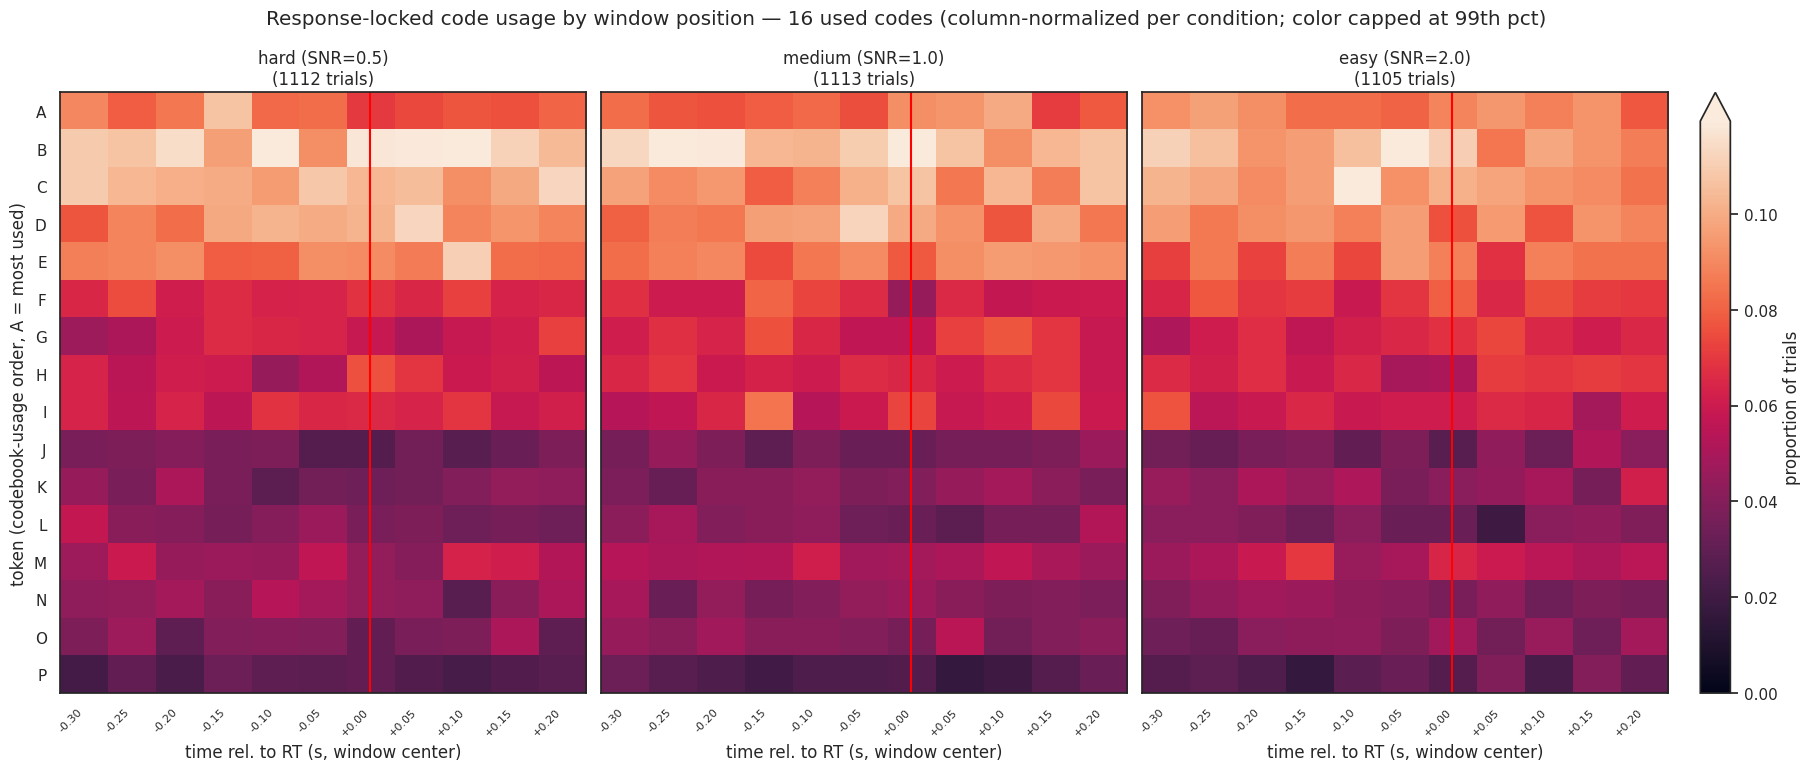

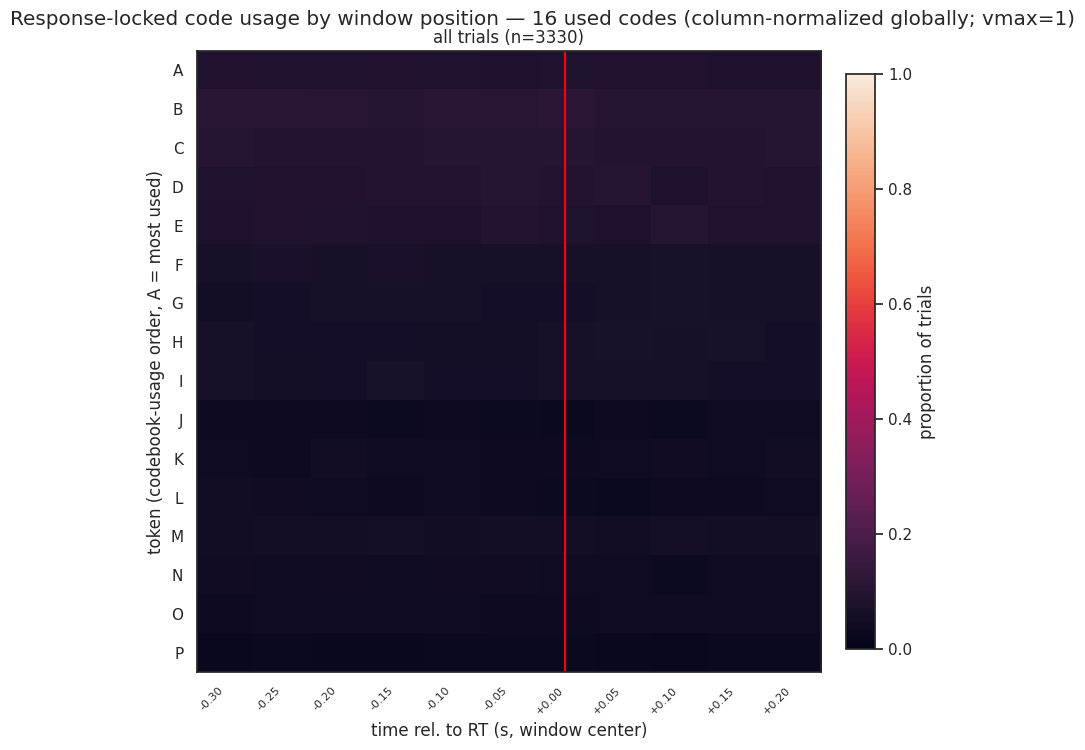

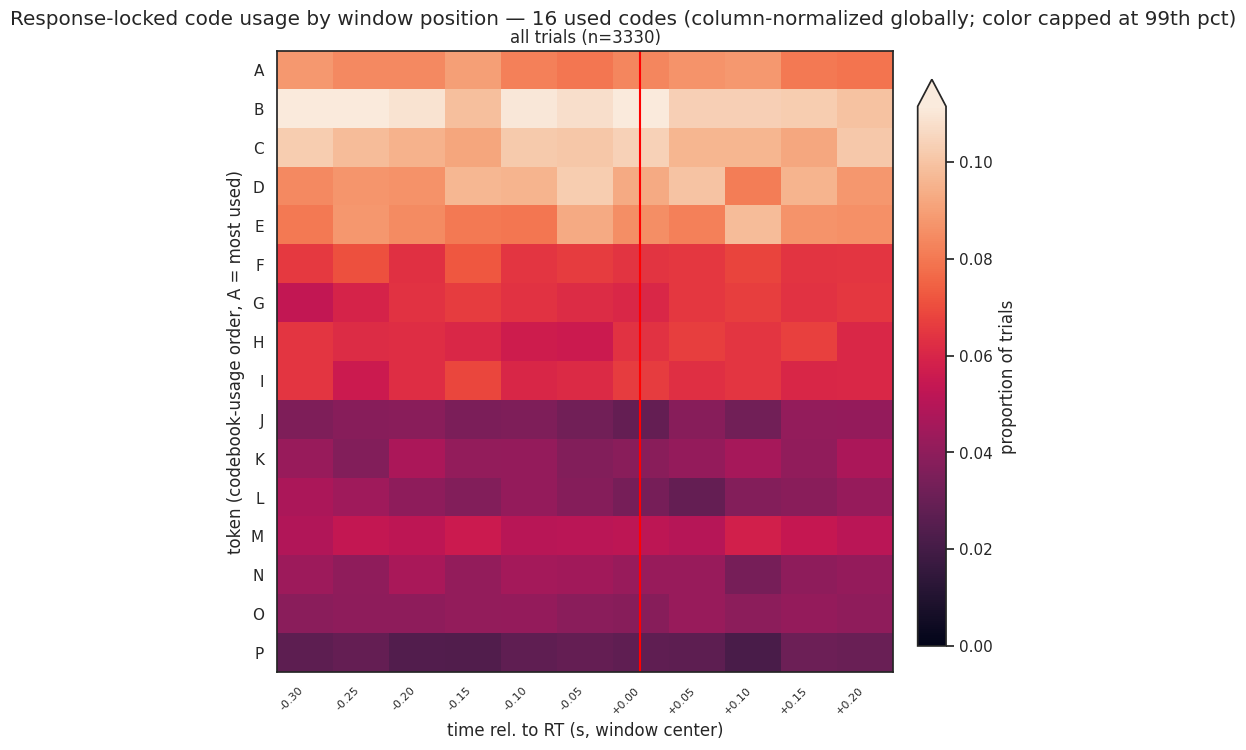

In [22]:
# ── Tokenize the response-locked windows and plot code usage vs. RT ─────
# split each 600 ms epoch into overlapping 150 ms windows (100 ms overlap, 50 ms
# hop) — the same chunking as the stimulus-locked analysis — and assign a token.
# Anchor the grid so ONE 150 ms window is centered exactly on the response
# (RT at t=0 -> middle of a chunk), then tile outward by STRIDE in both
# directions, keeping every window fully inside the 600 ms epoch.
CENTER_START = PRE_SAMPLES - CHUNK_SAMPLES // 2   # start of the RT-centered window
_k_min = int(np.ceil(-CENTER_START / STRIDE_SAMPLES))
_k_max = int(np.floor((TOTAL_SAMPLES - CHUNK_SAMPLES - CENTER_START) / STRIDE_SAMPLES))
RL_STARTS    = CENTER_START + np.arange(_k_min, _k_max + 1) * STRIDE_SAMPLES
RL_N_WINDOWS = len(RL_STARTS)
rl_windows = np.stack(
    [response_locked_data[:, :, s:s + CHUNK_SAMPLES] for s in RL_STARTS],
    axis=1,
).reshape(-1, C_data, CHUNK_SAMPLES)                   # (n_valid*RL_N_WINDOWS, C, CHUNK_SAMPLES)

@torch.no_grad()
def tokenize_windows(model, X, batch_size=BATCH_SIZE):
    model.eval()
    toks = []
    for i in range(0, len(X), batch_size):
        b = torch.from_numpy(X[i:i + batch_size]).float().to(device)
        embedding, _, _, _ = model.encoder(b)
        z_e = model.proj_down(embedding)
        _, t, _ = model.quantizer(z_e)
        toks.append(t.cpu().numpy())
    return np.concatenate(toks)

rl_tokens = tokenize_windows(model, rl_windows).reshape(n_valid, RL_N_WINDOWS)
print("response-locked tokens:", rl_tokens.shape)

# ============================================================================
# Same window-by-position heatmaps as "Window-by-position heatmaps (pruned +
# relabelled alphabet)", but response-locked: window positions are relative to
# RT (t=0), and the red line marks the response.
# Rows = ONLY the used codes, A,B,C,... by codebook usage (order_ids/letters).
# ============================================================================
CLIP_PERCENTILE = 99

# x-axis: window-CENTER times relative to RT (s). imshow draws positions at
# integer pixel centres 0..RL_N_WINDOWS-1, so tick at those and label with times.
rl_time = (RL_STARTS + CHUNK_SAMPLES / 2 - PRE_SAMPLES) / FS   # window-center times (s)

def _rt_xaxis(ax):
    ax.set_xticks(np.arange(RL_N_WINDOWS))
    ax.set_xticklabels([f"{t:+.2f}" for t in rl_time],
                       rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("time rel. to RT (s, window center)")
    # RT (t=0) sits between window centers -> place the marker by interpolation
    ax.axvline(np.interp(0.0, rl_time, np.arange(RL_N_WINDOWS)), color="red", lw=1.5)

def _letter_yaxis(ax, show_labels=True):
    ax.set_yticks(np.arange(n_rows))
    ax.set_yticklabels(row_letters if show_labels else [])
    if show_labels:
        ax.set_ylabel(YLABEL)

print(f"response-locked heatmaps with {n_rows} used codes (of K={CODEBOOK_SIZE}); "
      f"letters A..{row_letters[-1]}")

# ---------------------------------------------------------------------------
# per-SNR RAW COUNTS  (unclipped, then color-capped at 99th pct)
# ---------------------------------------------------------------------------
pos_counts_by_snr = {}
plot_vals = []
for snr, label in SNR_LEVELS:
    tr = np.where(rl_snr == snr)[0]
    pc = code_usage_per_position(rl_tokens[tr], RL_N_WINDOWS, CODEBOOK_SIZE)
    pos_counts_by_snr[snr] = pc
    plot_vals.append(pc[:, row_ids])
plot_vals = np.concatenate(plot_vals)

for clip in (None, CLIP_PERCENTILE):
    # unclipped: share ONE vmax (max across all conditions) so the colorbar is
    # truly comparable across the three subplots, not autoscaled per panel.
    vmax   = plot_vals.max() if clip is None else max(1, np.percentile(plot_vals, clip))
    extend = "neither" if clip is None else "max"
    cap    = "unclipped" if clip is None else f"color capped at {clip}th pct"
    fig, axes = plt.subplots(1, 3, figsize=(18, max(4.5, 0.45 * n_rows)),
                             constrained_layout=True)
    for ax, (snr, label) in zip(axes, SNR_LEVELS):
        im = ax.imshow(pos_counts_by_snr[snr][:, row_ids].T, aspect="auto",
                       origin="upper", cmap="rocket", vmin=0, vmax=vmax)
        _rt_xaxis(ax)
        ax.set_title(f"{label}\n({int(np.sum(rl_snr == snr))} trials)")
        _letter_yaxis(ax, show_labels=(ax is axes[0]))
    fig.colorbar(im, ax=axes, label="# windows assigned",
                 fraction=0.025, pad=0.02, extend=extend)
    fig.suptitle(f"Response-locked code usage by window position — {n_rows} used codes "
                 f"(y: A,B,C,... by codebook usage; {cap})", y=1.05)
    plt.show()

# ---------------------------------------------------------------------------
# per-SNR PROPORTIONS  P(token | window)   (vmax=1, then capped at 99th pct)
# ---------------------------------------------------------------------------
pos_props_by_snr = {}
plot_vals = []
for snr, label in SNR_LEVELS:
    pc = pos_counts_by_snr[snr]
    pp = pc / pc.sum(axis=1, keepdims=True)
    pos_props_by_snr[snr] = pp
    plot_vals.append(pp[:, row_ids])
plot_vals = np.concatenate(plot_vals)

for vmax, cap, extend in [
    (1.0, "vmax=1", "neither"),
    (np.percentile(plot_vals, CLIP_PERCENTILE),
     f"color capped at {CLIP_PERCENTILE}th pct", "max"),
]:
    fig, axes = plt.subplots(1, 3, figsize=(18, max(4.5, 0.45 * n_rows)),
                             constrained_layout=True)
    for ax, (snr, label) in zip(axes, SNR_LEVELS):
        im = ax.imshow(pos_props_by_snr[snr][:, row_ids].T, aspect="auto",
                       origin="upper", cmap="rocket", vmin=0, vmax=vmax)
        _rt_xaxis(ax)
        ax.set_title(f"{label}\n({int(np.sum(rl_snr == snr))} trials)")
        _letter_yaxis(ax, show_labels=(ax is axes[0]))
    fig.colorbar(im, ax=axes, label="proportion of trials",
                 fraction=0.025, pad=0.02, extend=extend)
    fig.suptitle(f"Response-locked code usage by window position — {n_rows} used codes "
                 f"(column-normalized per condition; {cap})", y=1.05)
    plt.show()

# ---------------------------------------------------------------------------
# GLOBAL (all trials) PROPORTIONS  (vmax=1, then capped at 99th pct)
# ---------------------------------------------------------------------------
pos_counts_all = code_usage_per_position(rl_tokens, RL_N_WINDOWS, CODEBOOK_SIZE)
pos_props_all  = pos_counts_all / pos_counts_all.sum(axis=1, keepdims=True)
plot_vals      = pos_props_all[:, row_ids]

for vmax, cap, extend in [
    (1.0, "vmax=1", "neither"),
    (np.percentile(plot_vals, CLIP_PERCENTILE),
     f"color capped at {CLIP_PERCENTILE}th pct", "max"),
]:
    fig, ax = plt.subplots(figsize=(8, max(4.5, 0.45 * n_rows)),
                           constrained_layout=True)
    im = ax.imshow(plot_vals.T, aspect="auto", origin="upper", cmap="rocket",
                   vmin=0, vmax=vmax)
    _rt_xaxis(ax)
    _letter_yaxis(ax, show_labels=True)
    ax.set_title(f"all trials (n={len(rl_tokens)})")
    fig.colorbar(im, ax=ax, label="proportion of trials",
                 fraction=0.046, pad=0.04, extend=extend)
    fig.suptitle(f"Response-locked code usage by window position — {n_rows} used codes "
                 f"(column-normalized globally; {cap})", y=1.02)
    plt.show()


entropy ceiling: log2(K=16) = 4.00 bits  ->  log2(n_codes=16) = 4.00 bits (pruned)

condition             trials  active/used   perplexity  norm-perp
  hard (SNR=0.5)       1112   16/16         14.77      0.92
  medium (SNR=1.0)     1113   16/16         14.86      0.93
  easy (SNR=2.0)       1105   16/16         14.98      0.94


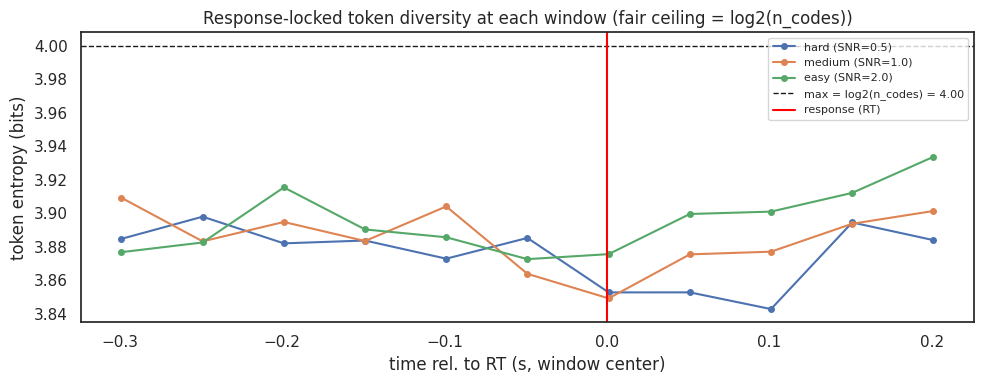


I(token; SNR) per window (response-locked): mean=0.0072  max=0.0122 bits  (ceiling = log2(#conditions=3) = 1.58)


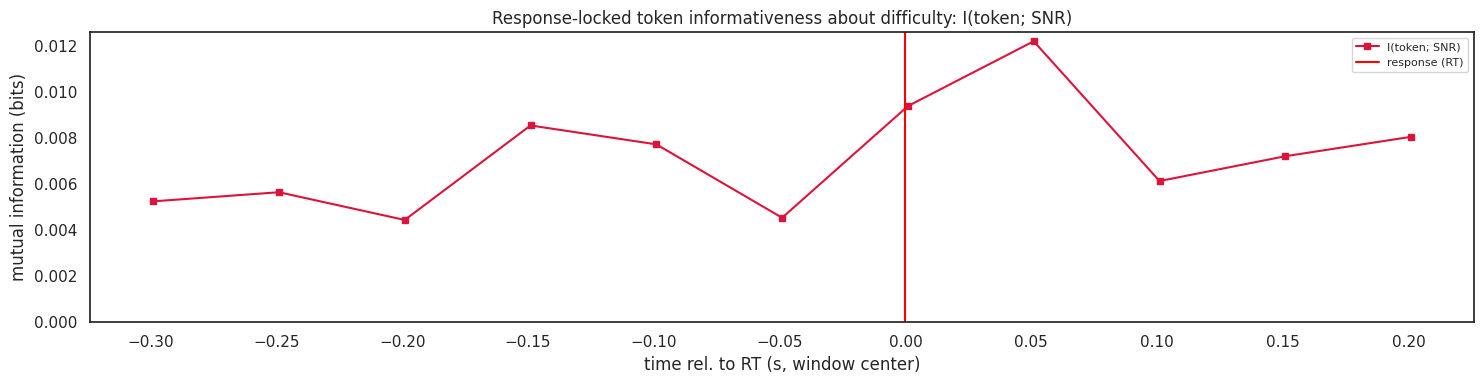


significant windows (p<0.05, 500 within-window shuffles): 1/11  (n=3330 trials)


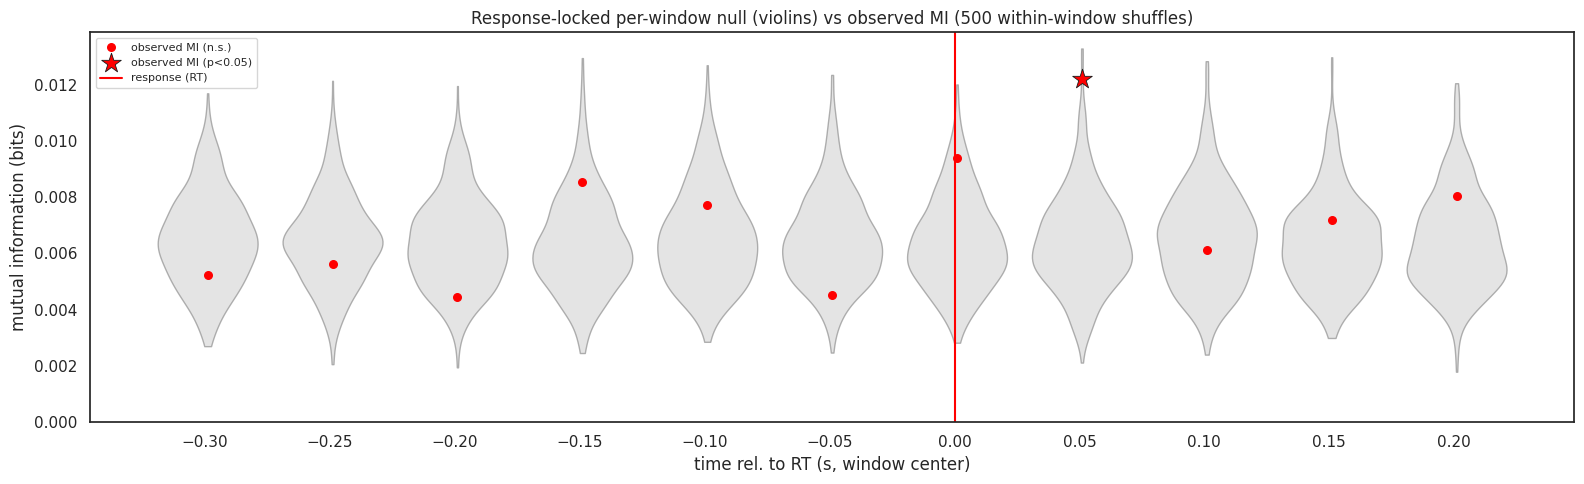

In [23]:
# ============================================================================
# Response-locked token diversity (entropy / perplexity) — mirrors the
# stimulus-locked "Token diversity / entropy" cell, but window positions are
# relative to RT (t=0). Uses rl_tokens / rl_snr / rl_time / RL_N_WINDOWS from the
# response-locked cells above and the pruned-alphabet basis (n_codes).
# ============================================================================
max_bits_K   = np.log2(CODEBOOK_SIZE)   # ceiling if all K codes were reachable
max_bits_use = np.log2(n_codes)         # fair ceiling: only the used codes
print(f"entropy ceiling: log2(K={CODEBOOK_SIZE}) = {max_bits_K:.2f} bits  ->  "
      f"log2(n_codes={n_codes}) = {max_bits_use:.2f} bits (pruned)")

# per-condition summary against the used-codes basis
print(f"\n{'condition':20s}  trials  active/used   perplexity  norm-perp")
for snr, label in SNR_LEVELS:
    tr = np.where(rl_snr == snr)[0]
    counts, used_cnt, perp = code_usage_summary(rl_tokens[tr], CODEBOOK_SIZE)
    norm_perp = perp / n_codes          # 1.0 == uniform over all used codes
    print(f"  {label:18s}  {len(tr):5d}   {used_cnt:2d}/{n_codes:<2d}"
          f"        {perp:6.2f}     {norm_perp:5.2f}")

# entropy per window position, per SNR; x-axis = window-center time relative to RT
ent_by_snr = {snr: token_entropy_by_position(rl_tokens[np.where(rl_snr == snr)[0]],
                                             CODEBOOK_SIZE)
              for snr, _ in SNR_LEVELS}

fig, ax = plt.subplots(figsize=(10, 4))
for snr, label in SNR_LEVELS:
    ax.plot(rl_time, ent_by_snr[snr], "-o", ms=4, label=label)
ax.axhline(max_bits_use, ls="--", color="k", lw=1,
           label=f"max = log2(n_codes) = {max_bits_use:.2f}")
ax.axvline(0.0, color="red", lw=1.5, label="response (RT)")
ax.set_xlabel("time rel. to RT (s, window center)")
ax.set_ylabel("token entropy (bits)")
ax.set_title("Response-locked token diversity at each window "
             "(fair ceiling = log2(n_codes))")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# --- mutual information per window: I(token; SNR), response-locked ------------
# Same metric as the stimulus-locked cell above; x-axis is time relative to RT.
snr_values = [snr for snr, _ in SNR_LEVELS]
mask_all   = np.isin(rl_snr, snr_values)
mi_pos     = token_condition_mi_by_position(rl_tokens[mask_all],
                                            rl_snr[mask_all], CODEBOOK_SIZE)
print(f"\nI(token; SNR) per window (response-locked): "
      f"mean={mi_pos.mean():.4f}  max={mi_pos.max():.4f} bits"
      f"  (ceiling = log2(#conditions={len(snr_values)}) = {np.log2(len(snr_values)):.2f})")

_, ax_mi = plt.subplots(figsize=(15, 4))
ax_mi.plot(rl_time, mi_pos, "-s", ms=4, color="crimson", label="I(token; SNR)")
ax_mi.axvline(0.0, color="red", lw=1.5, label="response (RT)")
ax_mi.set_xlabel("time rel. to RT (s, window center)")
ax_mi.set_ylabel("mutual information (bits)")
ax_mi.set_title("Response-locked token informativeness about difficulty: I(token; SNR)")
ax_mi.set_ylim(bottom=0)
ax_mi.locator_params(axis="x", nbins=20)
ax_mi.legend(fontsize=8)
plt.tight_layout()
plt.show()

# --- permutation null (within-window SNR shuffles) + violin significance ------
mi_ceiling = np.log2(len(snr_values))

def _col_mi(col, cond, num_codes, conds):
    """I(token; cond) in bits for a single window column."""
    joint = np.stack([np.bincount(col[cond == c], minlength=num_codes)
                      for c in conds], axis=1).astype(float)
    total = joint.sum()
    if total == 0:
        return 0.0
    pj   = joint / total
    ptok = pj.sum(axis=1, keepdims=True)
    pcnd = pj.sum(axis=0, keepdims=True)
    m    = pj > 0
    return float(np.sum(pj[m] * np.log2(pj[m] / (ptok * pcnd)[m])))

N_SHUFFLES = 500
rng        = np.random.default_rng(0)
tok_all    = rl_tokens[mask_all]
cond_all   = rl_snr[mask_all]
conds      = np.unique(cond_all)
n_pos      = tok_all.shape[1]

null_bits = np.zeros((N_SHUFFLES, n_pos))
for s in range(N_SHUFFLES):
    for p in range(n_pos):
        shuffled = rng.permutation(cond_all)
        null_bits[s, p] = _col_mi(tok_all[:, p], shuffled, CODEBOOK_SIZE, conds)

obs_bits = mi_pos
p_win = (1 + np.sum(null_bits >= obs_bits[None, :], axis=0)) / (N_SHUFFLES + 1)
sig   = p_win < 0.05
print(f"\nsignificant windows (p<0.05, {N_SHUFFLES} within-window shuffles): "
      f"{int(sig.sum())}/{n_pos}  (n={len(cond_all)} trials)")

_, axv = plt.subplots(figsize=(16, 5))
dt = float(np.median(np.diff(rl_time))) if n_pos > 1 else 1.0
parts = axv.violinplot([null_bits[:, p] for p in range(n_pos)],
                       positions=rl_time, widths=0.8 * dt, showextrema=False)
for pc in parts["bodies"]:
    pc.set_facecolor("lightgrey")
    pc.set_edgecolor("grey")
    pc.set_alpha(0.6)

axv.scatter(rl_time[~sig], obs_bits[~sig], color="red", s=30, zorder=5,
            label="observed MI (n.s.)")
axv.scatter(rl_time[sig], obs_bits[sig], marker="*", color="red", s=220,
            edgecolor="k", linewidths=0.6, zorder=6, label="observed MI (p<0.05)")
axv.axvline(0.0, color="red", lw=1.5, label="response (RT)")

axv.set_xlabel("time rel. to RT (s, window center)")
axv.set_ylabel("mutual information (bits)")
axv.set_title(f"Response-locked per-window null (violins) vs observed MI "
              f"({N_SHUFFLES} within-window shuffles)")
axv.set_ylim(bottom=0)
axv.locator_params(axis="x", nbins=20)
axv.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Amplitude scalp topomaps

Scalp projections of each amplitude code, one row per code (usage order), one column per band. Sensor positions come from `CHANNEL_NAMES` via `MONTAGE`. 

*(Topomaps apply to amplitude, a per-channel quantity. Coherence is a channel-by-channel quantity, shown as matrices above; a scalp view of coherence needs a connectivity layout such as a head-with-edges plot, not a single-value topomap.)*

In [24]:
# ── setup: variables the topomap cells need (from the codebook .npz) ─────
d           = np.load(CODEBOOK_NPZ, allow_pickle=True)   # same file loaded earlier
descriptor  = str(d["descriptor"])
counts      = d["counts"].astype(int)
n_filt      = int(d["n_filt"])
C           = int(d["n_channels"])
band_labels = [str(b) for b in d["band_labels"]]

# channel names in descriptor-channel order. Topoplot channels are `reducedchans`
# (the 0-based subset kept); the GSN-HydroCel-128 cap labels electrodes E1..E128.
channel_names = [f"E{c + 1}" for c in reducedchans]
assert len(channel_names) == C, f"{len(channel_names)} names but descriptor has C={C}"

# codes in usage order (A = most used), matching order_ids / letters
used   = np.where(counts > 0)[0]
order  = used[np.argsort(-counts[used], kind="stable")]
labels = code_labels(len(order))

import mne
mne.set_log_level("ERROR")

def make_info(channel_names, montage):
    info = mne.create_info(channel_names, sfreq=1000.0, ch_types="eeg")
    try:
        info.set_montage(montage, on_missing="warn")
    except Exception as e:
        print(f"Could not set montage {montage!r}: {e}")
    return info

MONTAGE = "GSN-HydroCel-128"
if descriptor == "amplitude":
    _info = make_info(channel_names, MONTAGE)
    _pos = _info.get_montage().get_positions()["ch_pos"]
    _missing = [c for c in channel_names
                if c not in _pos or not np.all(np.isfinite(list(_pos[c])))]
    if _missing:
        print(f"WARNING: no scalp position for {_missing} - they read as blank.")
    else:
        print(f"All {len(channel_names)} channels placed on {MONTAGE!r}.")
else:
    print(f"descriptor is {descriptor!r} - topomaps apply to amplitude only.")

All 98 channels placed on 'GSN-HydroCel-128'.


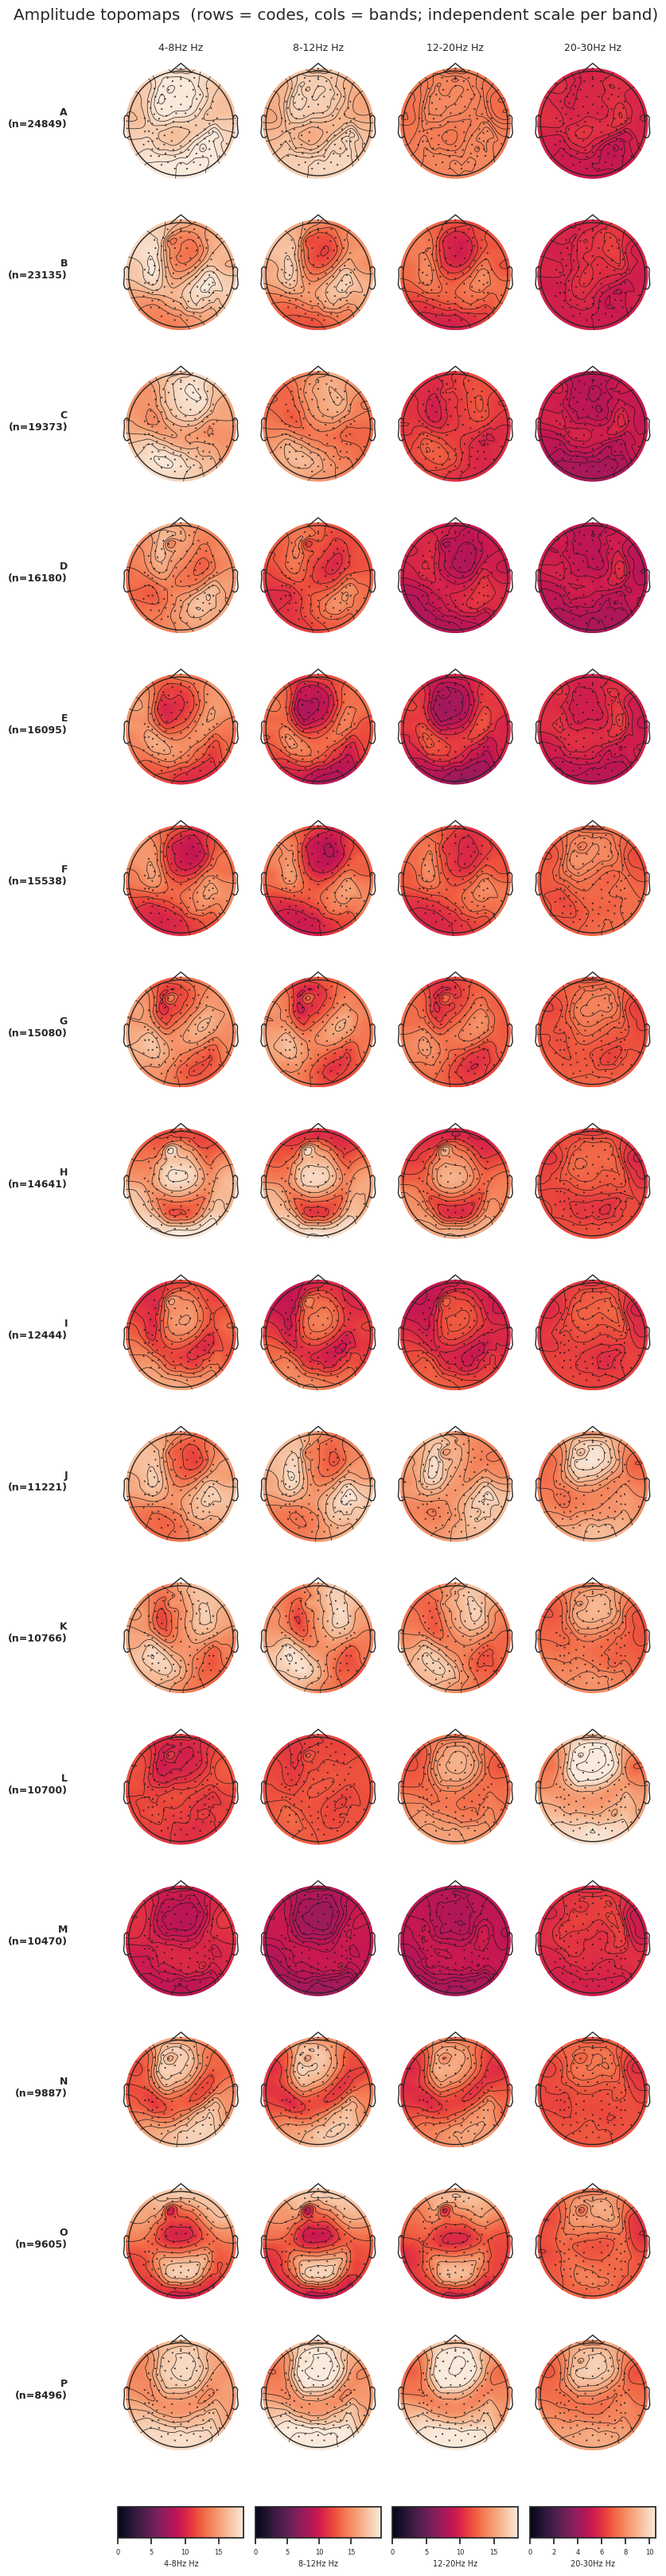

In [25]:
if descriptor == "amplitude":
    amp    = d["amplitude_maps"]                       # (K, n_filt, C)
    rocket = plt.get_cmap("rocket")
    # INDEPENDENT scale per band: each band gets its own vmax from its own data,
    # so low-amplitude high-frequency bands are not washed out by the low bands.
    band_vmax = [float(np.percentile(amp[order, b], 99)) for b in range(n_filt)]
    band_vmax = [v if v > 0 else 1.0 for v in band_vmax]

    nrow = len(order)
    # extra bottom space for one horizontal colourbar under each band column
    fig, axes = plt.subplots(nrow, n_filt, figsize=(n_filt*2.1, nrow*2.0 + 0.8),
                             squeeze=False)
    ims = [None] * n_filt
    for r, k in enumerate(order):
        for b in range(n_filt):
            ax = axes[r][b]
            ims[b], _ = mne.viz.plot_topomap(amp[k, b], _info, axes=ax, show=False,
                                             cmap=rocket, vlim=(0, band_vmax[b]),
                                             contours=6, extrapolate="head")
            if r == 0:
                ax.set_title(f"{band_labels[b]} Hz", fontsize=9)
        axes[r][0].text(-0.4, 0.5, f"{labels[r]}\n(n={int(counts[k])})",
                        transform=axes[r][0].transAxes, fontsize=9,
                        va="center", ha="right", weight="bold")

    # leave room at the bottom, then add one horizontal colourbar per column,
    # aligned under that column, each with its own band-specific scale
    fig.tight_layout(rect=[0, 0.06, 1, 1])
    for b in range(n_filt):
        pos = axes[nrow-1][b].get_position()       # bottom panel of column b
        cax = fig.add_axes([pos.x0, 0.035, pos.width, 0.012])
        cb = fig.colorbar(ims[b], cax=cax, orientation="horizontal")
        cb.ax.tick_params(labelsize=6)
        cb.set_label(f"{band_labels[b]} Hz", fontsize=7)
    fig.suptitle("Amplitude topomaps  (rows = codes, cols = bands; "
                 "independent scale per band)", y=1.005)
    plt.show()
else:
    print("Topomaps apply to amplitude only.")